In [1]:
# WEB DEV TEAM PLEASE DELETE BEFORE PUBLISHING - DS TEAM PLEASE KEEP IN THE FINAL VERSION OF THE USE CASE

from IPython.core.display import HTML
HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700&family=Inter:wght@400;500&display=swap');
body,p,li,div{font-family:'Inter',sans-serif}
body{counter-reset:h2counter}
.usecase-header-bar,.usecase-title,.usecase-section-heading,.usecase-sub-section-heading,.usecase-sub-sub-section-heading,.usecase-unnumbered-heading{font-family:'Poppins',sans-serif}
.usecase-header-bar{padding:16px 20px;background-color:#059669;color:#fff;border-radius:6px 6px 0 0}
.usecase-title{font-size:1.9em;font-weight:800}
.usecase-details{padding-left:20px;padding-bottom:8px;padding-top:8px;font-size:1.1em;color:#121212}
.usecase-section-heading,.usecase-unnumbered-heading{font-weight:700;font-size:1.35em;color:#059669;padding:14px 4px 6px 4px;border-bottom:3px solid #2DBE6C;margin-top:10px}
.usecase-section-heading::before{content:none!important}
.usecase-sub-section-heading{font-weight:600;font-size:1.15em;color:#059669;margin-top:8px}
.usecase-sub-section-heading::before{content:none!important}
.usecase-sub-sub-section-heading{font-weight:500;font-size:1.05em;color:#059669;margin-top:6px}
.usecase-sub-sub-section-heading::before{content:none!important}
.usecase-body{font-size:1em;color:#121212;line-height:1.6;margin-bottom:8px}
.usecase-list{line-height:1.7}
.usecase-list ul,.usecase-list ol{padding-left:24px;margin-top:8px;margin-bottom:12px}
.usecase-list li{margin-bottom:6px}
.usecase-datasets{background-color:rgba(5,150,105,.06);border-left:4px solid #059669;padding:12px 20px;border-radius:0 4px 4px 0;margin-top:12px}
.usecase-datasets ul{margin-top:8px;margin-bottom:8px}
.usecase-contents a,.usecase-datasets a{color:#059669;text-decoration:none}
.usecase-datasets a{font-weight:500}
.usecase-contents a:hover,.usecase-datasets a:hover{text-decoration:underline}
.usecase-contents{line-height:1.9;padding-left:20px}
</style>
""")

<div class="usecase-header-bar">
    <div class="usecase-title">Hospitality Venue Capacity Forecasting</div>
</div>

<div class="usecase-details"><b>Author: </b>Venuka Hirushan Wijenayake</div>
<div class="usecase-details"><b>Created: </b>Trimester 2, 2024</div>
<div class="usecase-details"><b>Updated: </b>Trimester 2, 2026 (Soorya)</div>
<div class="usecase-details"><b>Time to Complete: </b>90 mins</div>
<div class="usecase-details"><b>Level: </b>Intermediate</div>
<div class="usecase-details"><b>Pre-requisite Skills: </b>Python, pandas, basic machine learning concepts</div>


<div id="scenario" class="usecase-unnumbered-heading"><b>Scenario</b></div>

<div class="usecase-body"><b>As a</b> data scientist working with the Melbourne City Planning Department, <b>I want to</b> analyse historical seating and patron capacity records for Melbourne's bars, pubs, cafes and restaurants, <b>so that I can</b> identify patterns in hospitality capacity across the city and forecast how capacity may change in future years.</div>

<div class="usecase-body">To answer this, the use case retrieves two City of Melbourne datasets, cleans and combines them, explores how capacity is distributed across venue types and locations, and then applies two forecasting approaches: a time series model for individual properties and a Random Forest model trained across all properties.</div>

<div id="what-this-teaches" class="usecase-unnumbered-heading"><b>What this use case will teach you</b></div>

<div class="usecase-body">By the end of this use case you will be able to:</div>

<div class="usecase-list">

- Retrieve open datasets from the City of Melbourne Open Data API using Python
- Clean two related datasets by handling missing location values and de-duplicating records by property
- Explore seating and patron capacity with charts and interactive maps
- Merge datasets on a shared property identifier and measure the relationship between seating and patron capacity
- Summarise seating capacity by location and by the number of venue records at each address
- Forecast capacity for an individual property with an ARIMA time series model
- Train and evaluate Random Forest regression models and use them to predict capacity for future years

</div>

<div id="background" class="usecase-unnumbered-heading"><b>Background</b></div>

<div class="usecase-body">The City of Melbourne runs a Census of Land Use and Employment (CLUE), which records the businesses operating across the municipality. Two CLUE datasets describe hospitality capacity: one records the <b>number of seats</b> at cafes and restaurants, and the other records the <b>patron capacity</b> of bars, taverns and pubs. Both identify each venue by a property identifier and record its location, so the two datasets can be linked.</div>

<div class="usecase-body">Many properties appear in only a few census years, so each has a short history of observations. That shapes the modelling in this use case: forecasts built from a handful of data points need to be interpreted with care, and the notebook points out where this matters. The data is retrieved directly from the City of Melbourne Open Data API, so no manual download is needed.</div>

<div id="data-sets" class="usecase-unnumbered-heading"><b>Data Sets</b></div>

<div class="usecase-body">Two City of Melbourne datasets are used, both from the CLUE census and retrieved live through the API.</div>

<div class="usecase-datasets">

- [Café, restaurant, bistro seats](https://data.melbourne.vic.gov.au/explore/dataset/cafes-and-restaurants-with-seating-capacity/information/): seating capacity records for cafes and restaurants across Melbourne
- [Bar, tavern, pub patron capacity](https://data.melbourne.vic.gov.au/explore/dataset/bars-and-pubs-with-patron-capacity/information/): patron capacity records for bars, taverns and pubs across Melbourne

</div>

<div id="contents" class="usecase-unnumbered-heading"><b>Contents</b></div>

<div class="usecase-contents">

<ol>
<li><a href="#section-1">Initialisation</a>
<div style="margin-left:24px;">1.1. <a href="#subsection-1-1">Import Required Libraries</a></div>
<div style="margin-left:24px;">1.2. <a href="#subsection-1-2">Dataset Import Through API</a></div>
<div style="margin-left:24px;">1.3. <a href="#subsection-1-3">Records Contained in the Datasets</a></div>
<div style="margin-left:24px;">1.4. <a href="#subsection-1-4">Preview the Data</a></div>
</li>
<li><a href="#section-2">Preprocessing Data</a>
<div style="margin-left:24px;">2.1. <a href="#subsection-2-1">Displaying Available Columns</a></div>
<div style="margin-left:24px;">2.2. <a href="#subsection-2-2">Check and Remove Irrelevant Columns</a></div>
<div style="margin-left:24px;">2.3. <a href="#subsection-2-3">Identifying Missing Values</a></div>
<div style="margin-left:24px;">2.4. <a href="#subsection-2-4">Handle Missing Values in Bars and Pubs Dataset</a></div>
<div style="margin-left:24px;">2.5. <a href="#subsection-2-5">Handle Missing Values in Cafes and Restaurants Dataset</a></div>
<div style="margin-left:24px;">2.6. <a href="#subsection-2-6">Identify Records with Missing Locations After Update</a></div>
<div style="margin-left:24px;">2.7. <a href="#subsection-2-7">Remove Specific Records by Property ID</a></div>
<div style="margin-left:24px;">2.8. <a href="#subsection-2-8">De-duplicate Bars and Pubs Data</a></div>
<div style="margin-left:24px;">2.9. <a href="#subsection-2-9">De-duplicate Cafes and Restaurants Data</a></div>
<div style="margin-left:24px;">2.10. <a href="#subsection-2-10">Verify Missing Values</a></div>
</li>
<li><a href="#section-3">Exploratory Data Analysis</a>
<div style="margin-left:24px;">3.1. <a href="#subsection-3-1">Top 20 Bars/Pubs with the Highest Patron Capacity</a></div>
<div style="margin-left:24px;">3.2. <a href="#subsection-3-2">Top 20 Cafes/Restaurants with the Highest Seating Capacity</a></div>
<div style="margin-left:24px;">3.3. <a href="#subsection-3-3">Patron Distribution</a></div>
<div style="margin-left:24px;">3.4. <a href="#subsection-3-4">Box Plot for the Number of Patrons</a></div>
<div style="margin-left:24px;">3.5. <a href="#subsection-3-5">Seating Type Distribution</a></div>
<div style="margin-left:24px;">3.6. <a href="#subsection-3-6">Top 5 Industry Distribution</a></div>
<div style="margin-left:24px;">3.7. <a href="#subsection-3-7">Interactive Map Visualisation for Bars and Pubs</a></div>
<div style="margin-left:24px;">3.8. <a href="#subsection-3-8">Interactive Map Visualisation for Cafes and Restaurants</a></div>
<div style="margin-left:24px;">3.9. <a href="#subsection-3-9">Merge Datasets</a></div>
<div style="margin-left:24px;">3.10. <a href="#subsection-3-10">Correlation Matrix for Seating Capacity and Patron Capacity</a></div>
<div style="margin-left:24px;">3.11. <a href="#subsection-3-11">Relationship Between Seating Capacity and Patron Capacity</a></div>
<div style="margin-left:24px;">3.12. <a href="#subsection-3-12">Interactive Map for Merged Bars, Pubs, Restaurants and Cafes</a></div>
<div style="margin-left:24px;">3.13. <a href="#subsection-3-13">Changes in Seating Capacity and Patron Capacity Over Time</a></div>
<div style="margin-left:24px;">3.14. <a href="#subsection-3-14">Boxplot for Seating Capacity Among Different Industries</a></div>
<div style="margin-left:24px;">3.15. <a href="#subsection-3-15">Seating Capacity by Industry and Seating Type</a></div>
</li>
<li><a href="#section-4">Analysing Seating Capacity by Location</a>
<div style="margin-left:24px;">4.1. <a href="#subsection-4-1">Filter Data Based on Business Type</a></div>
<div style="margin-left:24px;">4.2. <a href="#subsection-4-2">Analyse the Distribution of Seating Capacities</a></div>
<div style="margin-left:24px;">4.3. <a href="#subsection-4-3">Identify High-Capacity Locations</a></div>
<div style="margin-left:24px;">4.4. <a href="#subsection-4-4">Visualise High-Capacity Locations</a></div>
<div style="margin-left:24px;">4.5. <a href="#subsection-4-5">Locations with High Capacity and Many Venue Records</a></div>
<div style="margin-left:24px;">4.6. <a href="#subsection-4-6">Mapping Locations with High Capacity and Fewer Venues</a></div>
</li>
<li><a href="#section-5">Predicting Future Seating and Patron Capacities</a>
<div style="margin-left:24px;">5.1. <a href="#subsection-5-1">Time Series (ARIMA) Model to Predict Patron and Seating Capacities</a></div>
<div style="margin-left:48px;">5.1.1. <a href="#subsubsection-5-1-1">Data Preparation</a></div>
<div style="margin-left:48px;">5.1.2. <a href="#subsubsection-5-1-2">Time Series Forecasting for Cafes and Restaurants</a></div>
<div style="margin-left:48px;">5.1.3. <a href="#subsubsection-5-1-3">Time Series Forecasting for Bars and Pubs</a></div>
<div style="margin-left:24px;">5.2. <a href="#subsection-5-2">Random Forest Model to Predict Patron and Seating Capacities</a></div>
<div style="margin-left:48px;">5.2.1. <a href="#subsubsection-5-2-1">Data Preprocessing and Feature Engineering</a></div>
<div style="margin-left:48px;">5.2.2. <a href="#subsubsection-5-2-2">Model Training</a></div>
<div style="margin-left:48px;">5.2.3. <a href="#subsubsection-5-2-3">Prediction for Future Years (2024 to 2028)</a></div>
</li>
<li style="list-style:none;"><a href="#conclusion">Conclusion</a></li>
</ol>

</div>

<div id="section-1" class="usecase-section-heading"><b>1. Initialisation</b></div>

<div class="usecase-body">This section sets up the environment and retrieves both datasets from the City of Melbourne Open Data API.</div>

<div id="subsection-1-1" class="usecase-sub-section-heading"><b>1.1 Import Required Libraries</b></div>

<div class="usecase-body">Import the libraries used throughout the notebook: <code>requests</code> and <code>pandas</code> for retrieving and handling data, <code>geopandas</code> and <code>folium</code> for maps, <code>matplotlib</code> and <code>seaborn</code> for charts, <code>ipywidgets</code> for dropdown controls, <code>statsmodels</code> for the ARIMA models and <code>scikit-learn</code> for the Random Forest models. Convergence and date-index warnings are switched off so they do not clutter the output. If a library is missing, install it with <code>pip install &lt;package-name&gt;</code> and run the cell again.</div>

In [2]:
import warnings
warnings.filterwarnings('ignore')

import requests
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
from folium.plugins import MarkerCluster
import ipywidgets as widgets
from IPython.display import display, clear_output

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap

from io import StringIO
from statsmodels.tsa.arima.model import ARIMA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning, EstimationWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=ValueWarning)
warnings.filterwarnings('ignore', category=EstimationWarning)

# MOP template colour palette
MOP_PALETTE = ['#059669', '#9333EA', '#F97316', '#2563EB', '#EAB308', '#EC4899']
MOP_GREEN = MOP_PALETTE[0]
mop_heatmap_cmap = ListedColormap([MOP_GREEN])  # solid MOP colour only - no interpolated shades

# Base map for all folium maps. Esri's light grey canvas loads without an API key in Jupyter and Colab
# (OpenStreetMap blocks notebook tile requests, and CARTO now requires a key)
MAP_TILES = 'https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}'
MAP_ATTR = 'Tiles &copy; Esri &mdash; Esri, HERE, Garmin, &copy; OpenStreetMap contributors'

# Marker cluster bubbles in MOP green (folium's default clusters use their own green/yellow/orange)
MOP_CLUSTER_ICON = """
function(cluster) {
    return L.divIcon({
        html: '<div style="background-color:#059669;color:#FFFFFF;border-radius:50%;width:36px;height:36px;line-height:36px;text-align:center;font-weight:600;">' + cluster.getChildCount() + '</div>',
        className: 'mop-marker-cluster',
        iconSize: L.point(36, 36)
    });
}
"""


<div id="subsection-1-2" class="usecase-sub-section-heading"><b>1.2 Dataset Import Through API</b></div>

<div class="usecase-body">The <code>collect_data</code> function requests a full dataset from the portal's export endpoint as a CSV file and loads it into a pandas DataFrame. Setting <code>limit</code> to <code>-1</code> asks for every record rather than a single page of results. These datasets are open, so no API key is needed. If the request fails, the function prints the status code instead of returning data.</div>

In [3]:
#Function to collect data
def collect_data(dataset_id):
    base_url = 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
    #apikey = api_key #use if use datasets API_key permissions
    dataset_id = dataset_id
    format = 'csv'

    url = f'{base_url}{dataset_id}/exports/{format}'
    params = {
        'select': '*',
        'limit': -1,  # all records
        'lang': 'en',
        'timezone': 'UTC',
        #'api_key': apikey  #use if use datasets API_key permissions
    }

    # GET request
    response = requests.get(url, params=params)

    if response.status_code == 200:
        # StringIO to read the CSV data
        url_content = response.content.decode('utf-8')
        dataset = pd.read_csv(StringIO(url_content), delimiter=';')
        return dataset
    else:
        print(f'Request failed with status code {response.status_code}')

<div class="usecase-body">Running this cell prints nothing because it only defines the function. It is called in the next step.</div>

<div id="subsection-1-3" class="usecase-sub-section-heading"><b>1.3 Records Contained in the Datasets</b></div>

<div class="usecase-body">Call <code>collect_data</code> once for each dataset and print the number of records returned. Each record is one venue in one census year, so the same property can appear many times.</div>

In [4]:
# Set dataset_id to query for the API call dataset name
dataset_id1 = 'bars-and-pubs-with-patron-capacity'
dataset_id2 = 'cafes-and-restaurants-with-seating-capacity'
# Save dataset to df variable
bars_pubs = collect_data(dataset_id1)
cafes_restaurants = collect_data(dataset_id2)
# Check number of records in df
print(f'The dataset contains {len(bars_pubs)} records.')
print(f'The dataset contains {len(cafes_restaurants)} records.')

The dataset contains 5304 records.
The dataset contains 66356 records.


<div class="usecase-body">The Cafes and Restaurants dataset contains far more records than the Bars and Pubs dataset. The counts can change when the City of Melbourne updates the datasets.</div>

<div id="subsection-1-4" class="usecase-sub-section-heading"><b>1.4 Preview the Data</b></div>

<div class="usecase-body">Display the first three rows of each dataset to see what the columns contain before any cleaning.</div>

In [5]:
print("Bars and Pubs Dataset:")
display(bars_pubs.head(3))

print("\nCafes and Restaurants Dataset:")
display(cafes_restaurants.head(3))

Bars and Pubs Dataset:


,census_year,block_id,property_id,base_property_id,building_address,clue_small_area,trading_name,business_address,number_of_patrons,longitude,latitude,location
0,2002,11,108972,108972,10-22 Spencer Street MELBOURNE 3000,Melbourne (CBD),Explorers Inn,10-22 Spencer Street MELBOURNE 3000,50,144.955252,-37.820508,"-37.82050816, 144.955251611"
1,2002,16,104018,104018,172-192 Flinders Street MELBOURNE 3000,Melbourne (CBD),Purple Emerald,"Ground , 191 Flinders Street MELBOURNE 3000",100,144.968552,-37.816640,"-37.81663984, 144.96855231"
2,2002,23,102098,102098,415-417 Collins Street MELBOURNE 3000,Melbourne (CBD),The Sherlock Holmes Inn,"Basement , 415 Collins Street MELBOURNE 3000",70,144.960878,-37.817470,"-37.8174695, 144.960877534"



Cafes and Restaurants Dataset:


,census_year,block_id,property_id,base_property_id,building_address,clue_small_area,trading_name,business_address,industry_anzsic4_code,industry_anzsic4_description,seating_type,number_of_seats,longitude,latitude,location
0,2007,13,110151,110151,22-38 William Street MELBOURNE 3000,Melbourne (CBD),Cafe 22,"Part Ground , 22 William Street MELBOURNE 3000",4511,Cafes and Restaurants,Seats - Indoor,75,144.959975,-37.818778,"-37.8187779, 144.959974759"
1,2007,14,103166,103166,7-9 Elizabeth Street MELBOURNE 3000,Melbourne (CBD),Pepperoni's,7A Elizabeth Street MELBOURNE 3000,4511,Cafes and Restaurants,Seats - Indoor,70,144.964560,-37.817933,"-37.81793319, 144.964559723"
2,2007,14,103167,103167,11-15 Elizabeth Street MELBOURNE 3000,Melbourne (CBD),McDonald's,11-15 Elizabeth Street MELBOURNE 3000,4511,Cafes and Restaurants,Seats - Outdoor,12,144.964509,-37.817831,"-37.81783056, 144.964509018"


<div class="usecase-body">Each row is one venue in one census year, identified by <code>property_id</code>. Both datasets include the address, the CLUE small area, the trading name and a <code>location</code> column holding latitude and longitude as text. The capacity column differs: <code>number_of_patrons</code> for bars and pubs, and <code>number_of_seats</code> for cafes and restaurants, which also records the industry classification and seating type.</div>

<div id="section-2" class="usecase-section-heading"><b>2. Preprocessing Data</b></div>

<div class="usecase-body">Real-world data needs cleaning before it can be analysed. This section removes columns that are not needed, fills or removes missing location values, and de-duplicates the records so that each property is represented once.</div>

<div id="subsection-2-1" class="usecase-sub-section-heading"><b>2.1 Displaying Available Columns</b></div>

<div class="usecase-body">Understanding the available columns helps in identifying key features that will be used in the analysis and data processing steps.</div>

In [6]:
# Print available columns in Bars and Pubs dataset:
print("Available columns in Bars and Pubs dataset:")
print(bars_pubs.columns.tolist())

Available columns in Bars and Pubs dataset:
['census_year', 'block_id', 'property_id', 'base_property_id', 'building_address', 'clue_small_area', 'trading_name', 'business_address', 'number_of_patrons', 'longitude', 'latitude', 'location']


In [7]:
# Print available columns in Cafes and Restaurants dataset:
print("Available columns in Cafes and Restaurants dataset:")
print(cafes_restaurants.columns.tolist())

Available columns in Cafes and Restaurants dataset:
['census_year', 'block_id', 'property_id', 'base_property_id', 'building_address', 'clue_small_area', 'trading_name', 'business_address', 'industry_anzsic4_code', 'industry_anzsic4_description', 'seating_type', 'number_of_seats', 'longitude', 'latitude', 'location']


<div class="usecase-body">The two datasets share the census year, property identifiers, address, trading name and location fields. The Cafes and Restaurants dataset adds the industry description, seating type and number of seats, while the Bars and Pubs dataset adds the number of patrons.</div>

<div id="subsection-2-2" class="usecase-sub-section-heading"><b>2.2 Check and Remove Irrelevant Columns</b></div>

<div class="usecase-body">In this step, columns that are not needed for the analysis are removed from both datasets. This keeps the data focused on the fields actually used later, including the location field (<code>clue_small_area</code>), which is kept rather than removed since it becomes a predictor for the Random Forest models in Section 5.2. The latitude and longitude columns are dropped, since the same coordinates are held in <code>location</code>, which is split back into coordinates later when the maps are drawn.</div>

In [8]:
# Columns to remove from each dataset
# clue_small_area is kept, since it becomes a real location feature for the Random Forest models later
columns_to_remove_bars_pubs = ['block_id', 'base_property_id', 'business_address', 'latitude', 'longitude']
columns_to_remove_cafes_restaurants = ['block_id', 'base_property_id', 'industry_anzsic4_code', 'business_address', 'latitude', 'longitude']

# Remove irrelevant columns
bars_pubs_updated = bars_pubs.drop(columns=columns_to_remove_bars_pubs)
cafes_restaurants_updated = cafes_restaurants.drop(columns=columns_to_remove_cafes_restaurants)

# Verify remaining columns
print("Remaining columns in Bars and Pubs dataset:")
print(bars_pubs_updated.columns.tolist())

print("Remaining columns in Cafes and Restaurants dataset:")
print(cafes_restaurants_updated.columns.tolist())

Remaining columns in Bars and Pubs dataset:
['census_year', 'property_id', 'building_address', 'clue_small_area', 'trading_name', 'number_of_patrons', 'location']
Remaining columns in Cafes and Restaurants dataset:
['census_year', 'property_id', 'building_address', 'clue_small_area', 'trading_name', 'industry_anzsic4_description', 'seating_type', 'number_of_seats', 'location']


<div class="usecase-body">The printed lists confirm which columns remain in each dataset.</div>

<div id="subsection-2-3" class="usecase-sub-section-heading"><b>2.3 Identifying Missing Values</b></div>

<div class="usecase-body">Count the missing values in each column. Missing values need to be handled before analysis because they can cause errors in calculations and maps.</div>

In [9]:
# Check for missing values in the Bars and Pubs dataset
missing_values_bars_pubs = bars_pubs_updated.isnull().sum()
print("Missing values in Bars and Pubs dataset:")
print(missing_values_bars_pubs)

# Check for missing values in the Cafes and Restaurants dataset
missing_values_cafes_restaurants = cafes_restaurants_updated.isnull().sum()
print("Missing values in Cafes and Restaurants dataset:")
print(missing_values_cafes_restaurants)

Missing values in Bars and Pubs dataset:
census_year           0
property_id           0
building_address      0
clue_small_area       0
trading_name          0
number_of_patrons     0
location             20
dtype: int64
Missing values in Cafes and Restaurants dataset:
census_year                       0
property_id                       0
building_address                  0
clue_small_area                   0
trading_name                      0
industry_anzsic4_description      0
seating_type                      0
number_of_seats                   0
location                        527
dtype: int64


<div class="usecase-body">Only the <code>location</code> column has gaps in either dataset. Sections 2.4 to 2.7 deal with them.</div>

<div id="subsection-2-4" class="usecase-sub-section-heading"><b>2.4 Handle Missing Values in Bars and Pubs Dataset</b></div>

<div class="usecase-body">A small number of Bars and Pubs records have no <code>location</code> in the API response. Each of these addresses appears in several census years, and at least one of those records does include a location, so the gap can be filled from another record for the same <code>building_address</code> (the mode) - the same approach used for the Cafes and Restaurants dataset in Section 2.5. This uses only the data returned by the API, so no extra reference file is needed. If a future update of the dataset contains an address with no location in any of its records, it is reported and removed, since it cannot be placed on a map.</div>

In [10]:
# Fill missing locations from another record for the same building_address (the mode),
# the same approach used for the Cafes and Restaurants dataset in 2.5
address_to_location_map_bars_pubs = bars_pubs_updated.groupby('building_address')['location'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
)

bars_pubs_cleaned = bars_pubs_updated.copy()
bars_pubs_cleaned['location'] = bars_pubs_cleaned.apply(
    lambda row: address_to_location_map_bars_pubs[row['building_address']] if pd.isnull(row['location']) else row['location'],
    axis=1
)

# Report and remove any addresses that still have no location in any census year
still_missing_addresses = bars_pubs_cleaned.loc[bars_pubs_cleaned['location'].isnull(), 'building_address'].unique()
if len(still_missing_addresses) > 0:
    print(f"{len(still_missing_addresses)} address(es) have no location in any census year and are removed:")
    print(list(still_missing_addresses))
    bars_pubs_cleaned = bars_pubs_cleaned[bars_pubs_cleaned['location'].notnull()]
else:
    print("Every missing location was filled from another record at the same address.")

Every missing location was filled from another record at the same address.


<div class="usecase-body">The output confirms whether every missing location was filled. The same address can appear more than once in the dataset because it has records in several census years.</div>

<div id="subsection-2-5" class="usecase-sub-section-heading"><b>2.5 Handle Missing Values in Cafes and Restaurants Dataset</b></div>

<div class="usecase-body">Each address in the Cafes and Restaurants dataset appears in many census years, so a missing location can often be filled from another record for the same address. The code finds the most common <code>location</code> for each <code>building_address</code> (the mode) and uses it to fill any gaps.</div>

In [11]:
# Step 1: Create a mapping of 'building_address' to the most common 'location'
address_to_location_map = cafes_restaurants_updated.groupby('building_address')['location'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)

# Step 2: Fill missing 'location' values using the mapping
cafes_restaurants_updated['location'] = cafes_restaurants_updated.apply(
    lambda row: address_to_location_map[row['building_address']] if pd.isnull(row['location']) else row['location'],
    axis=1
)

# Verify if the missing values are filled
missing_values_after_filling = cafes_restaurants_updated['location'].isnull().sum()
print(f"Missing values in 'location' after filling: {missing_values_after_filling}")

Missing values in 'location' after filling: 7


<div class="usecase-body">The count printed is the number of locations that are still missing. These are addresses that have no location recorded in any census year, so they cannot be filled this way.</div>

<div id="subsection-2-6" class="usecase-sub-section-heading"><b>2.6 Identify Records with Missing Locations After Update</b></div>

<div class="usecase-body">List the records that still have no location so they can be inspected before deciding what to do with them.</div>

In [12]:
# Check for missing values in the 'location' column after filling
remaining_missing_locations = cafes_restaurants_updated[cafes_restaurants_updated['location'].isnull()]

# Display the records with missing 'location' values
print("Records with missing 'location' values after update:")
print(remaining_missing_locations)

Records with missing 'location' values after update:
       census_year  property_id                     building_address  \
12937         2002       101345     0 Campbell Arcade MELBOURNE 3000   
13527         2003       101345     0 Campbell Arcade MELBOURNE 3000   
15470         2005       111240  0 Evan Walker Bridge SOUTHBANK 3006   
29555         2004       101345     0 Campbell Arcade MELBOURNE 3000   
30156         2004       111240  0 Evan Walker Bridge SOUTHBANK 3006   
36521         2012       101345     0 Flinders Street MELBOURNE 3000   
37544         2013       101345     0 Flinders Street MELBOURNE 3000   

       clue_small_area   trading_name  \
12937  Melbourne (CBD)       Bar Rush   
13527  Melbourne (CBD)       Bar Rush   
15470        Southbank  Clem's Island   
29555  Melbourne (CBD)        Jetcall   
30156        Southbank  Clem's Island   
36521  Melbourne (CBD)   Cup of Truth   
37544  Melbourne (CBD)   Cup of Truth   

                            industry_anzs

<div class="usecase-body">The remaining records belong to a small number of properties whose location is missing in every year they appear.</div>

<div id="subsection-2-7" class="usecase-sub-section-heading"><b>2.7 Remove Specific Records by Property ID</b></div>

<div class="usecase-body">Because these properties have no location anywhere in the data, they cannot be placed on a map or matched to a CLUE small area reliably. They are removed by property ID.</div>

In [13]:
# Define the Property IDs to remove
property_ids_to_remove = [101345, 111240]

# Remove the rows with the specified Property IDs
cafes_restaurants_updated = cafes_restaurants_updated[~cafes_restaurants_updated['property_id'].isin(property_ids_to_remove)]

# Verify that the records have been removed
print(f"Records after removing Property IDs {property_ids_to_remove}:")
print(cafes_restaurants_updated[cafes_restaurants_updated['property_id'].isin(property_ids_to_remove)])

Records after removing Property IDs [101345, 111240]:
Empty DataFrame
Columns: [census_year, property_id, building_address, clue_small_area, trading_name, industry_anzsic4_description, seating_type, number_of_seats, location]
Index: []


<div class="usecase-body">The empty DataFrame confirms that no records remain for the removed property IDs.</div>

<div id="subsection-2-8" class="usecase-sub-section-heading"><b>2.8 De-duplicate Bars and Pubs Data</b></div>

<div class="usecase-body">A property can appear once for every census year. To analyse each venue once, the code keeps the single record with the highest <code>number_of_patrons</code> for each <code>property_id</code>. The <code>idxmax</code> function returns the row position of that maximum within each group. Each property is therefore represented by the census year in which its patron capacity was highest.</div>

In [14]:
# Group by 'property_id' and find the index of the row with the maximum 'number_of_patrons' for each group
idx = bars_pubs_cleaned.groupby(['property_id'])['number_of_patrons'].idxmax()

# Use the indices to filter the DataFrame
bars_pubs_deduplicated = bars_pubs_cleaned.loc[idx].reset_index(drop=True)

# Verify the deduplicated DataFrame
print("Deduplicated Bars and Pubs dataset:")
print(bars_pubs_deduplicated.head())

Deduplicated Bars and Pubs dataset:
   census_year  property_id                            building_address  \
0         2008       100160     196-200 A'Beckett Street MELBOURNE 3000   
1         2010       100441  118-126 Ireland Street WEST MELBOURNE 3003   
2         2003       100514   204-206 Arden Street NORTH MELBOURNE 3051   
3         2005       100727               5-9 Bank Place MELBOURNE 3000   
4         2010       100730             12-16 Bank Place MELBOURNE 3000   

                clue_small_area                               trading_name  \
0               Melbourne (CBD)                Nomads Industry Backpackers   
1  West Melbourne (Residential)                              Railway Hotel   
2               North Melbourne  North Melbourne Football Club Social Club   
3               Melbourne (CBD)                               Mitre Tavern   
4               Melbourne (CBD)                      Melbourne Savage Club   

   number_of_patrons                     loc

<div class="usecase-body">The preview shows one row per property. The <code>census_year</code> column now records the year in which each property's highest capacity was found.</div>

<div id="subsection-2-9" class="usecase-sub-section-heading"><b>2.9 De-duplicate Cafes and Restaurants Data</b></div>

<div class="usecase-body">The same approach is applied to the Cafes and Restaurants dataset, keeping the record with the highest <code>number_of_seats</code> for each property.</div>

In [15]:
# Group by 'property_id' and find the index of the row with the maximum 'number_of_seats' for each group
idx_cafes_restaurants = cafes_restaurants_updated.groupby(['property_id'])['number_of_seats'].idxmax()

# Use the indices to filter the DataFrame and remove duplicates
cafes_restaurants_deduplicated = cafes_restaurants_updated.loc[idx_cafes_restaurants].reset_index(drop=True)

# Verify the deduplicated DataFrame
print("Deduplicated Cafes and Restaurants dataset:")
print(cafes_restaurants_deduplicated.head())

Deduplicated Cafes and Restaurants dataset:
   census_year  property_id                                building_address  \
0         2002       100041      253 Abbotsford Street NORTH MELBOURNE 3051   
1         2002       100084  515-517 Abbotsford Street NORTH MELBOURNE 3051   
2         2007       100112  340-348 Abbotsford Street NORTH MELBOURNE 3051   
3         2002       100119  218-224 Abbotsford Street NORTH MELBOURNE 3051   
4         2012       100153           51-53 A'Beckett Street MELBOURNE 3000   

   clue_small_area                 trading_name industry_anzsic4_description  \
0  North Melbourne              Abbot's Seafood       Takeaway Food Services   
1  North Melbourne           La Dish Fine Foods       Takeaway Food Services   
2  North Melbourne  Papa Guiseppe Pizza & Pasta       Takeaway Food Services   
3  North Melbourne             North Star Hotel       Pubs, Taverns and Bars   
4  Melbourne (CBD)            Darac Grill & Bar        Cafes and Restaurants   



<div class="usecase-body">As before, the result has one row per property.</div>

<div id="subsection-2-10" class="usecase-sub-section-heading"><b>2.10 Verify Missing Values</b></div>

<div class="usecase-body">Repeat the missing value check on the de-duplicated datasets to confirm the cleaning steps worked.</div>

In [16]:
# Check for missing values in each column after deduplication in both datasets

# For Cafes and Restaurants
missing_values_cafes_restaurants = cafes_restaurants_deduplicated.isnull().sum()

# For Bars and Pubs
missing_values_bars_pubs = bars_pubs_deduplicated.isnull().sum()

# Print the number of missing values in each column
print("Missing values in Cafes and Restaurants dataset after deduplication:")
print(missing_values_cafes_restaurants)

print("\nMissing values in Bars and Pubs dataset after deduplication:")
print(missing_values_bars_pubs)

Missing values in Cafes and Restaurants dataset after deduplication:
census_year                     0
property_id                     0
building_address                0
clue_small_area                 0
trading_name                    0
industry_anzsic4_description    0
seating_type                    0
number_of_seats                 0
location                        0
dtype: int64

Missing values in Bars and Pubs dataset after deduplication:
census_year          0
property_id          0
building_address     0
clue_small_area      0
trading_name         0
number_of_patrons    0
location             0
dtype: int64


<div class="usecase-body">Every column now shows zero missing values in both datasets, so the data is ready for exploration.</div>

<div id="section-3" class="usecase-section-heading"><b>3. Exploratory Data Analysis</b></div>

<div class="usecase-body">Exploratory data analysis summarises the datasets with charts and maps to understand how capacity is distributed before combining them or building any models.</div>

<div id="subsection-3-1" class="usecase-sub-section-heading"><b>3.1 Top 20 Bars/Pubs with the Highest Patron Capacity</b></div>

<div class="usecase-body">Sum the patron capacity for each trading name and plot the 20 largest as a horizontal bar chart, with the value labelled on each bar.</div>

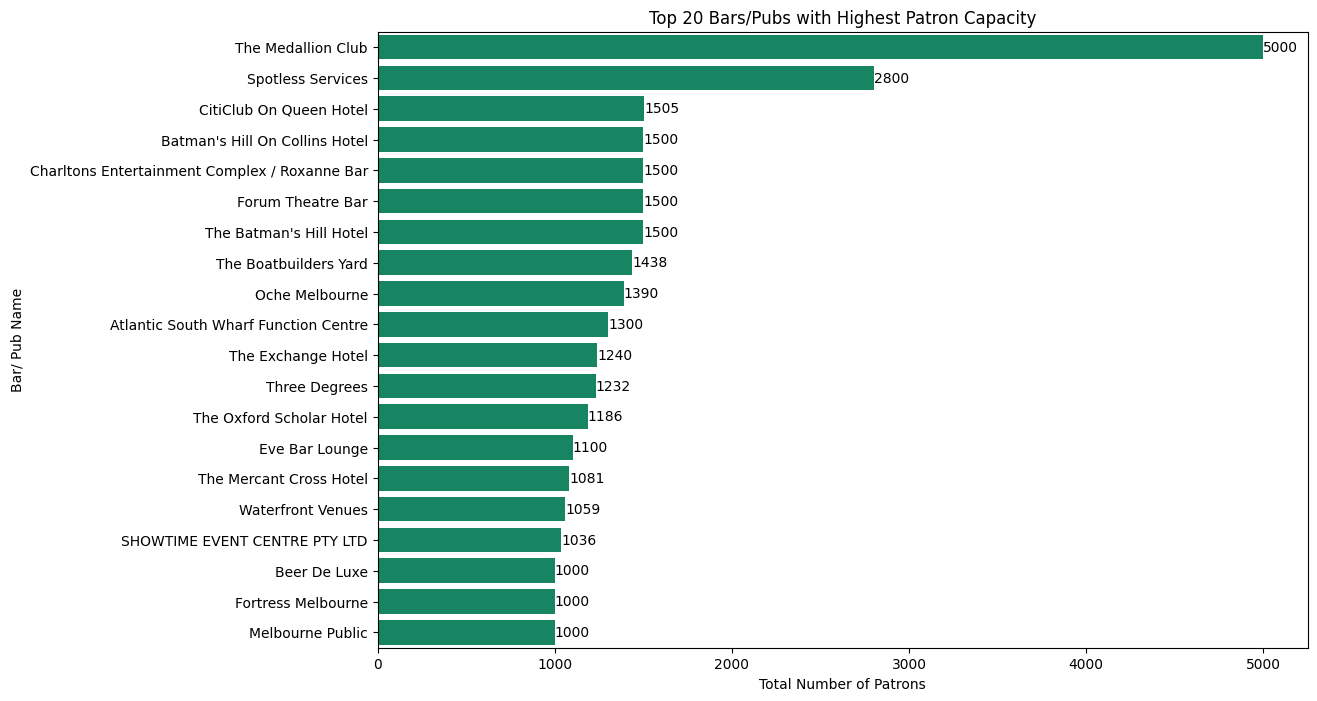

In [17]:
top_20_trading_names = bars_pubs_deduplicated.groupby('trading_name')['number_of_patrons'].sum().nlargest(20).reset_index()

# Create the bar plot
plt.figure(figsize=(12, 8))
bar_plot = sns.barplot(x='number_of_patrons', y='trading_name', data=top_20_trading_names, color=MOP_GREEN)

# Add the count on each bar
for index, row in top_20_trading_names.iterrows():
    bar_plot.text(row['number_of_patrons'], index, f'{row["number_of_patrons"]}', va='center')

plt.title('Top 20 Bars/Pubs with Highest Patron Capacity')
plt.xlabel('Total Number of Patrons')
plt.ylabel('Bar/ Pub Name')
plt.show()

<div class="usecase-body">A few names are much larger than the rest. Because capacities are summed by trading name, an organisation that operates several venues appears as a single bar.</div>

<div id="subsection-3-2" class="usecase-sub-section-heading"><b>3.2 Top 20 Cafes/Restaurants with the Highest Seating Capacity</b></div>

<div class="usecase-body">The same summary is produced for cafes and restaurants, using the number of seats.</div>

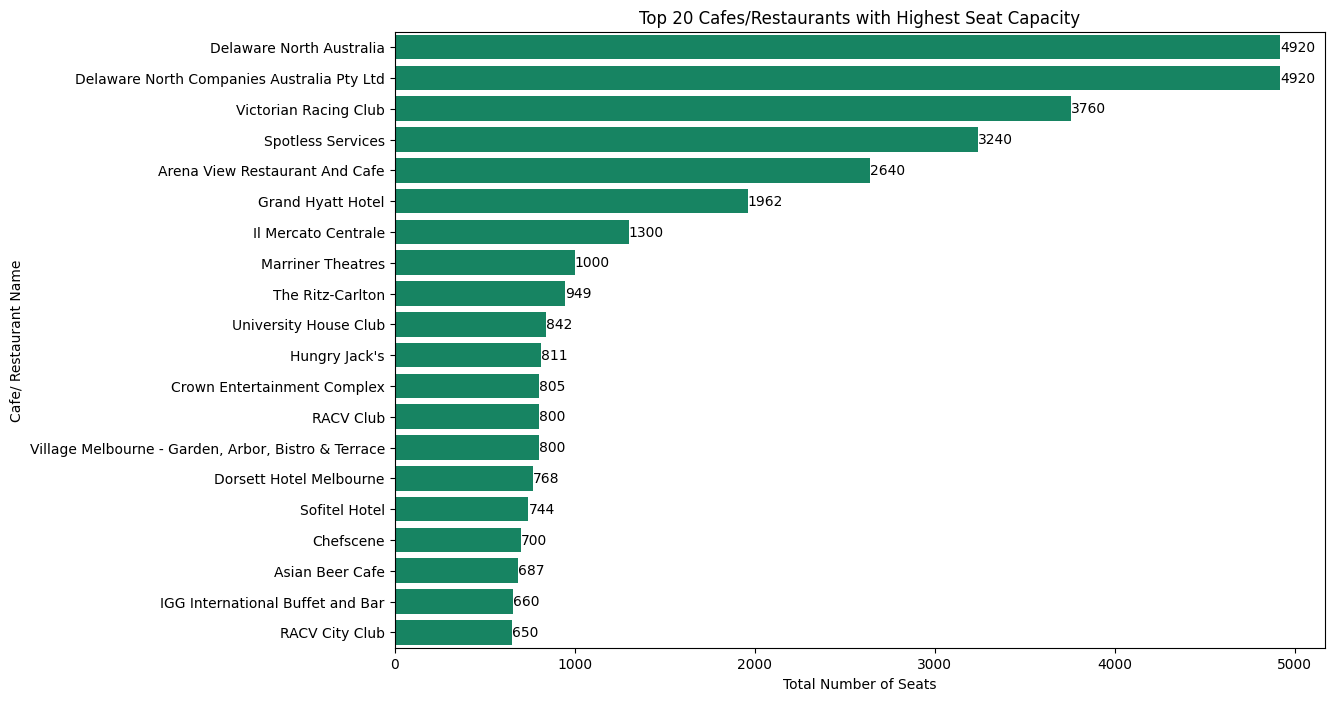

In [18]:
top_20_trading_names = cafes_restaurants_deduplicated.groupby('trading_name')['number_of_seats'].sum().nlargest(20).reset_index()

# Create the bar plot
plt.figure(figsize=(12, 8))
bar_plot = sns.barplot(x='number_of_seats', y='trading_name', data=top_20_trading_names, color=MOP_GREEN)

# Add the count on each bar
for index, row in top_20_trading_names.iterrows():
    bar_plot.text(row['number_of_seats'], index, f'{row["number_of_seats"]}', va='center')

plt.title('Top 20 Cafes/Restaurants with Highest Seat Capacity')
plt.xlabel('Total Number of Seats')
plt.ylabel('Cafe/ Restaurant Name')
plt.show()

<div class="usecase-body">As with bars and pubs, the totals combine all properties that share a trading name, so large operators and venues in large complexes stand out.</div>

<div id="subsection-3-3" class="usecase-sub-section-heading"><b>3.3 Patron Distribution</b></div>

<div class="usecase-body">A histogram shows how many bars and pubs fall into each range of patron capacity. The curve drawn over the bars is a kernel density estimate, a smoothed outline of the same distribution.</div>

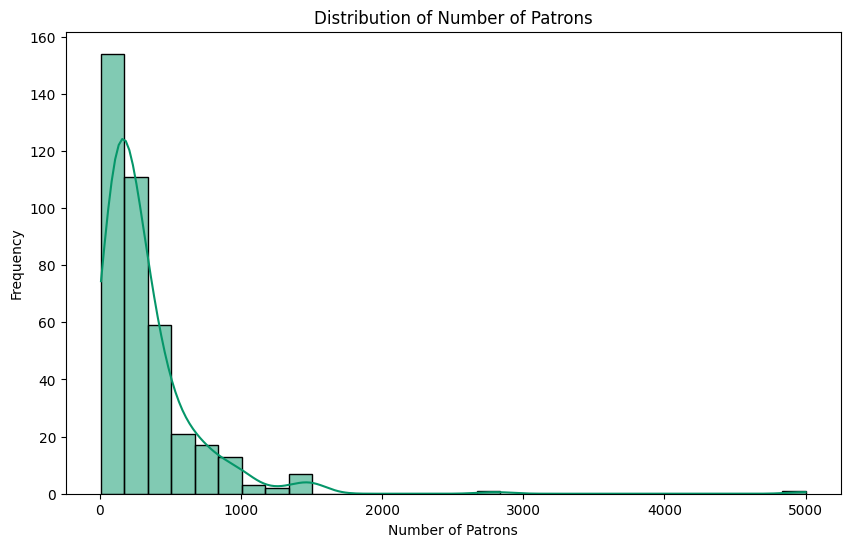

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(bars_pubs_deduplicated['number_of_patrons'], bins=30, kde=True, color=MOP_GREEN)
plt.title('Distribution of Number of Patrons')
plt.xlabel('Number of Patrons')
plt.ylabel('Frequency')
plt.show()

<div class="usecase-body">The distribution is right-skewed. Most venues have a patron capacity of a few hundred or fewer, and a small number of very large venues stretch the right-hand tail.</div>

<div id="subsection-3-4" class="usecase-sub-section-heading"><b>3.4 Box Plot for the Number of Patrons</b></div>

<div class="usecase-body">A box plot summarises the same values. The box covers the middle 50 per cent of venues, the line inside it marks the median, and points beyond the whiskers are treated as outliers.</div>

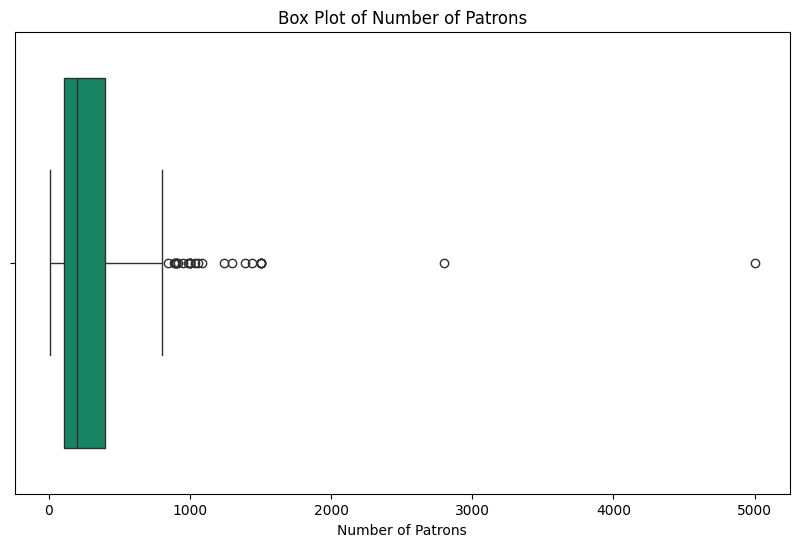

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=bars_pubs_deduplicated['number_of_patrons'], color=MOP_GREEN)
plt.title('Box Plot of Number of Patrons')
plt.xlabel('Number of Patrons')
plt.show()

<div class="usecase-body">The box sits at the low end of the scale, while the outliers to the right are the very large venues seen in the histogram and the top 20 chart.</div>

<div id="subsection-3-5" class="usecase-sub-section-heading"><b>3.5 Seating Type Distribution</b></div>

<div class="usecase-body">Count how many cafe and restaurant records are indoor seating and how many are outdoor, and show the split as a pie chart.</div>

Seating Type Distribution:
seating_type
Seats - Indoor     1749
Seats - Outdoor     169
Name: count, dtype: int64


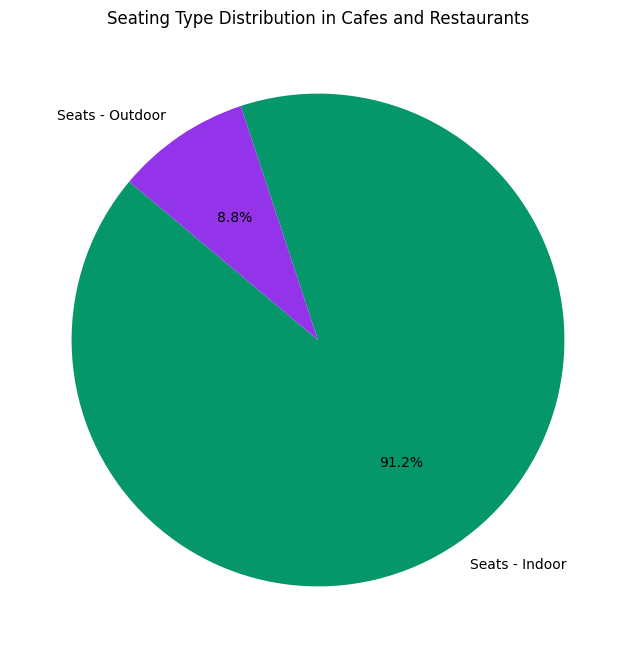

In [21]:
# Group by 'seating_type' and count the number of occurrences
seating_type_counts = cafes_restaurants_deduplicated['seating_type'].value_counts()

# Display the counts
print("Seating Type Distribution:")
print(seating_type_counts)

# Pie chart for seating type distribution
plt.figure(figsize=(8, 8))
plt.pie(seating_type_counts, labels=seating_type_counts.index, autopct='%1.1f%%', startangle=140, colors=MOP_PALETTE)
plt.title('Seating Type Distribution in Cafes and Restaurants')
plt.show()

<div class="usecase-body">Indoor seating makes up the large majority of records, with outdoor seating a much smaller share.</div>

<div id="subsection-3-6" class="usecase-sub-section-heading"><b>3.6 Top 5 Industry Distribution</b></div>

<div class="usecase-body">The Cafes and Restaurants dataset also contains other hospitality-related industry classifications (ANZSIC4). This step counts the records in each classification and shows the five most common.</div>

Top 5 Industry (ANZSIC4) Descriptions:
industry_anzsic4_description
Cafes and Restaurants     1437
Pubs, Taverns and Bars     163
Takeaway Food Services     151
Accommodation               67
Clubs (Hospitality)         12
Name: count, dtype: int64


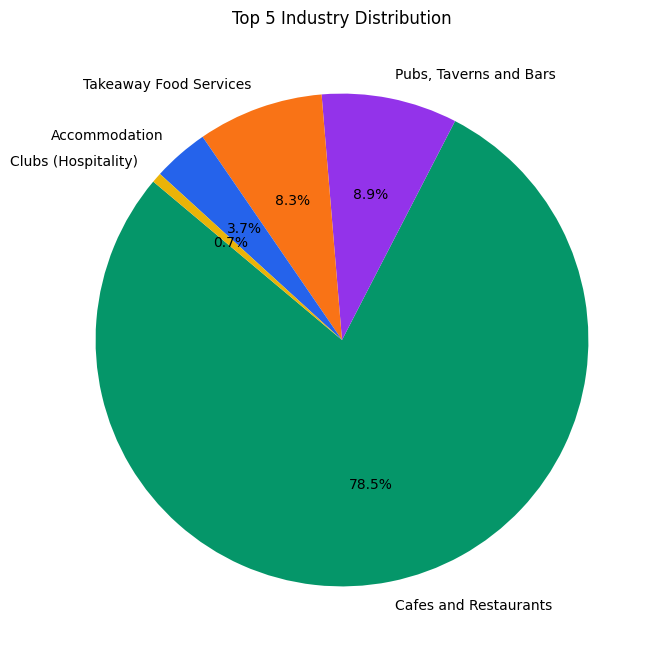

In [22]:
# Get the top 5 most common Industry descriptions
top_5_industries = cafes_restaurants_deduplicated['industry_anzsic4_description'].value_counts().nlargest(5)

# Display the top 5 industries
print("Top 5 Industry (ANZSIC4) Descriptions:")
print(top_5_industries)

# Pie chart for the top 5 Industry Description distribution
plt.figure(figsize=(8, 8))
plt.pie(top_5_industries, labels=top_5_industries.index, autopct='%1.1f%%', startangle=140, colors=MOP_PALETTE)
plt.title('Top 5 Industry Distribution')
plt.show()

<div class="usecase-body">Cafes and Restaurants is the dominant classification. Pubs, Taverns and Bars, Takeaway Food Services, Accommodation and Clubs (Hospitality) make up the remainder of the top five.</div>

<div id="subsection-3-7" class="usecase-sub-section-heading"><b>3.7 Interactive Map Visualisation for Bars and Pubs</b></div>

<div class="usecase-body">The <code>location</code> column stores latitude and longitude as one piece of text, so the code first splits it into two numeric columns. The data is then converted to a GeoDataFrame, which treats each venue as a point on the map. A dropdown lets you choose between showing all venues, grouped into clusters, or highlighting a single venue in purple.</div>

In [23]:
# Ensure latitude and longitude columns
bars_pubs_deduplicated[['latitude', 'longitude']] = bars_pubs_deduplicated['location'].str.split(',', expand=True)
bars_pubs_deduplicated['latitude'] = pd.to_numeric(bars_pubs_deduplicated['latitude'])
bars_pubs_deduplicated['longitude'] = pd.to_numeric(bars_pubs_deduplicated['longitude'])

# Convert DataFrame to GeoDataFrame
gdf_bars_pubs = gpd.GeoDataFrame(
    bars_pubs_deduplicated,
    geometry=gpd.points_from_xy(bars_pubs_deduplicated.longitude, bars_pubs_deduplicated.latitude),
    crs="EPSG:4326"
)

# Remove invalid or empty geometries
gdf_bars_pubs = gdf_bars_pubs[~gdf_bars_pubs['geometry'].is_empty]

# Define the interactive map function
def update_map_bars(trading_name):
    clear_output(wait=True)
    melbourne_map = folium.Map(location=[-37.8136, 144.9631], zoom_start=12, tiles=MAP_TILES, attr=MAP_ATTR)
    marker_cluster = MarkerCluster(icon_create_function=MOP_CLUSTER_ICON).add_to(melbourne_map)

    if trading_name == "All Locations":
        for idx, row in gdf_bars_pubs.iterrows():
            folium.CircleMarker(
                location=[row.geometry.y, row.geometry.x],
                radius=3,
                color=MOP_GREEN,
                fill=True,
                fill_color=MOP_GREEN,
                popup=f"Trading Name: {row['trading_name']}, Patrons: {row['number_of_patrons']}"
            ).add_to(marker_cluster)
    else:
        selected_gdf = gdf_bars_pubs[gdf_bars_pubs['trading_name'] == trading_name]
        for idx, row in selected_gdf.iterrows():
            folium.CircleMarker(
                location=[row.geometry.y, row.geometry.x],
                radius=8,
                color=MOP_PALETTE[1],
                fill=True,
                fill_color=MOP_PALETTE[1],
                popup=f"Trading Name: {row['trading_name']}, Patrons: {row['number_of_patrons']}"
            ).add_to(marker_cluster)

    display(melbourne_map)

# Create the dropdown widget
trading_name_dropdown_bars = widgets.Dropdown(
    options=["All Locations"] + list(gdf_bars_pubs['trading_name'].unique()),
    description='Select Bar/Pub:'
)

# Link the dropdown to the map update function
widgets.interact(update_map_bars, trading_name=trading_name_dropdown_bars);

interactive(children=(Dropdown(description='Select Bar/Pub:', options=('All Locations', 'Nomads Industry Backp…

<div class="usecase-body">Select different names in the dropdown to move between venues. When all locations are shown, the clusters split into individual markers as you zoom in, and clicking a marker shows the trading name and patron capacity.</div>

<div id="subsection-3-8" class="usecase-sub-section-heading"><b>3.8 Interactive Map Visualisation for Cafes and Restaurants</b></div>

<div class="usecase-body">The same process is applied to the Cafes and Restaurants dataset. Markers are green for all locations and orange for a selected venue, and the popup shows the number of seats.</div>

In [24]:
# Ensure latitude and longitude columns
cafes_restaurants_deduplicated[['latitude', 'longitude']] = cafes_restaurants_deduplicated['location'].str.split(',', expand=True)
cafes_restaurants_deduplicated['latitude'] = pd.to_numeric(cafes_restaurants_deduplicated['latitude'])
cafes_restaurants_deduplicated['longitude'] = pd.to_numeric(cafes_restaurants_deduplicated['longitude'])

# Convert DataFrame to GeoDataFrame
gdf_cafes_restaurants = gpd.GeoDataFrame(
    cafes_restaurants_deduplicated,
    geometry=gpd.points_from_xy(cafes_restaurants_deduplicated.longitude, cafes_restaurants_deduplicated.latitude),
    crs="EPSG:4326"
)

# Remove invalid or empty geometries
gdf_cafes_restaurants = gdf_cafes_restaurants[~gdf_cafes_restaurants['geometry'].is_empty]

# Define the interactive map function
def update_map_cafes(trading_name):
    clear_output(wait=True)
    melbourne_map = folium.Map(location=[-37.8136, 144.9631], zoom_start=12, tiles=MAP_TILES, attr=MAP_ATTR)
    marker_cluster = MarkerCluster(icon_create_function=MOP_CLUSTER_ICON).add_to(melbourne_map)

    if trading_name == "All Locations":
        for idx, row in gdf_cafes_restaurants.iterrows():
            folium.CircleMarker(
                location=[row.geometry.y, row.geometry.x],
                radius=3,
                color=MOP_GREEN,
                fill=True,
                fill_color=MOP_GREEN,
                popup=f"Trading Name: {row['trading_name']}, Seats: {row['number_of_seats']}"
            ).add_to(marker_cluster)
    else:
        selected_gdf = gdf_cafes_restaurants[gdf_cafes_restaurants['trading_name'] == trading_name]
        for idx, row in selected_gdf.iterrows():
            folium.CircleMarker(
                location=[row.geometry.y, row.geometry.x],
                radius=8,
                color=MOP_PALETTE[1],
                fill=True,
                fill_color=MOP_PALETTE[1],
                popup=f"Trading Name: {row['trading_name']}, Seats: {row['number_of_seats']}"
            ).add_to(marker_cluster)

    display(melbourne_map)

# Create the dropdown widget
trading_name_dropdown_cafes = widgets.Dropdown(
    options=["All Locations"] + list(gdf_cafes_restaurants['trading_name'].unique()),
    description='Select Cafe/Restaurant:'
)

# Link the dropdown to the map update function
widgets.interact(update_map_cafes, trading_name=trading_name_dropdown_cafes);

interactive(children=(Dropdown(description='Select Cafe/Restaurant:', options=('All Locations', "Abbot's Seafo…

<div class="usecase-body">Compare this map with the previous one to see where cafes and restaurants are concentrated relative to bars and pubs.</div>

<div id="subsection-3-9" class="usecase-sub-section-heading"><b>3.9 Merge Datasets</b></div>

<div class="usecase-body">Merge the two de-duplicated datasets with an inner join on <code>property_id</code>. An inner join keeps only properties that appear in both datasets, so the merged data holds both a seating capacity and a patron capacity for each property. Columns with the same name in both datasets are given the suffixes <code>_bars</code> and <code>_cafes</code> so they can be told apart.</div>

In [25]:
# Perform an inner merge based on 'property_id'
merged_df = pd.merge(bars_pubs_deduplicated, cafes_restaurants_deduplicated, on='property_id', how='inner', suffixes=('_bars', '_cafes'))

# Display the first few rows of the merged dataset
print(merged_df.head())

   census_year_bars  property_id                      building_address_bars  \
0              2008       100160    196-200 A'Beckett Street MELBOURNE 3000   
1              2003       100514  204-206 Arden Street NORTH MELBOURNE 3051   
2              2005       100727              5-9 Bank Place MELBOURNE 3000   
3              2010       100730            12-16 Bank Place MELBOURNE 3000   
4              2003       101023            25 Bennetts Lane MELBOURNE 3000   

  clue_small_area_bars                          trading_name_bars  \
0      Melbourne (CBD)                Nomads Industry Backpackers   
1      North Melbourne  North Melbourne Football Club Social Club   
2      Melbourne (CBD)                               Mitre Tavern   
3      Melbourne (CBD)                      Melbourne Savage Club   
4      Melbourne (CBD)                    Bennetts Lane Jazz Club   

   number_of_patrons                location_bars  latitude_bars  \
0                200  -37.80998494, 144.95

<div class="usecase-body">Each row now describes one property with columns from both datasets, such as <code>number_of_patrons</code> and <code>number_of_seats</code>.</div>

<div id="subsection-3-10" class="usecase-sub-section-heading"><b>3.10 Correlation Matrix for Seating Capacity and Patron Capacity</b></div>

<div class="usecase-body">The Pearson correlation coefficient measures the strength of a straight-line relationship between two variables, on a scale from -1 (opposite directions) to 1 (move together perfectly). A heatmap displays the correlation matrix and the coefficient is also printed.</div>

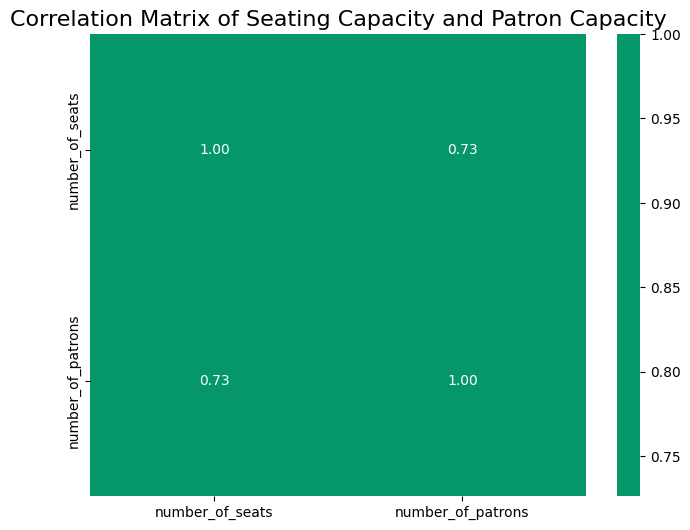

Pearson correlation coefficient between seating capacity and patron capacity: 0.7261116231266342


In [26]:
# Calculate the Pearson correlation coefficient
correlation = merged_df['number_of_seats'].corr(merged_df['number_of_patrons'])

# Calculate the correlation matrix
correlation_matrix = merged_df[['number_of_seats', 'number_of_patrons']].corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap=mop_heatmap_cmap, fmt=".2f")

# Customise the title
plt.title("Correlation Matrix of Seating Capacity and Patron Capacity", fontsize=16)

# Display the plot
plt.show()

print(f"Pearson correlation coefficient between seating capacity and patron capacity: {correlation}")

<div class="usecase-body">The coefficient between seating capacity and patron capacity is positive, meaning venues with more seats tend to have a higher patron capacity. The diagonal values of 1.00 simply show each variable correlated with itself.</div>

<div id="subsection-3-11" class="usecase-sub-section-heading"><b>3.11 Relationship Between Seating Capacity and Patron Capacity</b></div>

<div class="usecase-body">A scatter plot places each property at its seating capacity and patron capacity, and a regression line shows the overall trend.</div>

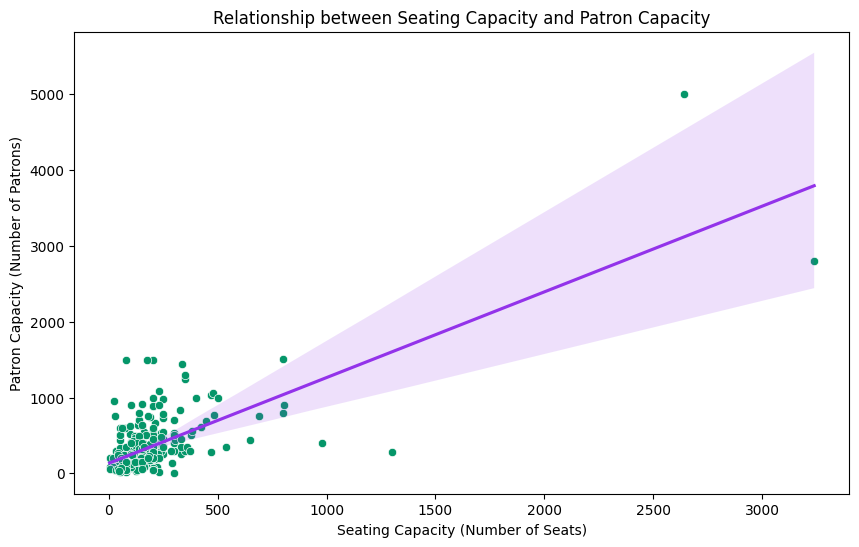

In [27]:
# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='number_of_seats', y='number_of_patrons', data=merged_df, color=MOP_GREEN)

# Add a regression line to highlight the trend
sns.regplot(x='number_of_seats', y='number_of_patrons', data=merged_df, scatter=False, color=MOP_PALETTE[1])

plt.title('Relationship between Seating Capacity and Patron Capacity')
plt.xlabel('Seating Capacity (Number of Seats)')
plt.ylabel('Patron Capacity (Number of Patrons)')
plt.show()

<div class="usecase-body">The points trend upwards, consistent with the positive correlation. The shaded band around the line shows the uncertainty in the fitted trend, and it widens where there are only a few large venues. A small number of properties sit well away from the line.</div>

<div id="subsection-3-12" class="usecase-sub-section-heading"><b>3.12 Interactive Map for Merged Bars, Pubs, Restaurants and Cafes</b></div>

<div class="usecase-body">Plot the merged properties on a map. The dropdown either shows every property or zooms to a single one, and the popup shows its seating and patron capacity together.</div>

In [28]:
# Function to update the map based on dropdown selection
def update_map(trading_name):
    # Clear the previous output
    clear_output(wait=True)

    # Create the map
    if trading_name == "All Locations":
        updated_map = folium.Map(location=[-37.8136, 144.9631], zoom_start=12, tiles=MAP_TILES, attr=MAP_ATTR)
        for _, row in merged_df.iterrows():
            location = [float(coord) for coord in row['location_bars'].split(', ')]
            popup_text = f"{row['trading_name_bars']}: Seats {row['number_of_seats']}, Patrons {row['number_of_patrons']}"
            folium.CircleMarker(
                location=location,
                radius=6,
                color=MOP_GREEN,
                fill=True,
                fill_color=MOP_GREEN,
                fill_opacity=0.8,
                popup=popup_text,
                tooltip=row['trading_name_bars']
            ).add_to(updated_map)
    else:
        selected_row = merged_df[merged_df['trading_name_bars'] == trading_name].iloc[0]
        location = [float(coord) for coord in selected_row['location_bars'].split(', ')]
        popup_text = f"{selected_row['trading_name_bars']}: Seats {selected_row['number_of_seats']}, Patrons {selected_row['number_of_patrons']}"
        updated_map = folium.Map(location=location, zoom_start=15, tiles=MAP_TILES, attr=MAP_ATTR)
        folium.CircleMarker(
            location=location,
            radius=10,
            color=MOP_GREEN,
            fill=True,
            fill_color=MOP_GREEN,
            fill_opacity=0.8,
            popup=popup_text,
            tooltip=selected_row['trading_name_bars']
        ).add_to(updated_map)

    # Display the updated map
    display(updated_map)

# Create a dropdown for selecting the establishment, with an option for "All Locations"
dropdown = widgets.Dropdown(
    options=["All Locations"] + list(merged_df['trading_name_bars'].unique()),
    description='Select Place:',
    disabled=False,
)

# Link the dropdown to the update_map function
widgets.interact(update_map, trading_name=dropdown);

interactive(children=(Dropdown(description='Select Place:', options=('All Locations', 'Nomads Industry Backpac…

<div class="usecase-body">Use the dropdown to look at individual properties. Because these properties appear in both datasets, each popup shows both capacity figures.</div>

<div id="subsection-3-13" class="usecase-sub-section-heading"><b>3.13 Changes in Seating Capacity and Patron Capacity Over Time</b></div>

<div class="usecase-body">Group the merged data by census year and add up the seating and patron capacity in each year, then plot both totals as lines.</div>

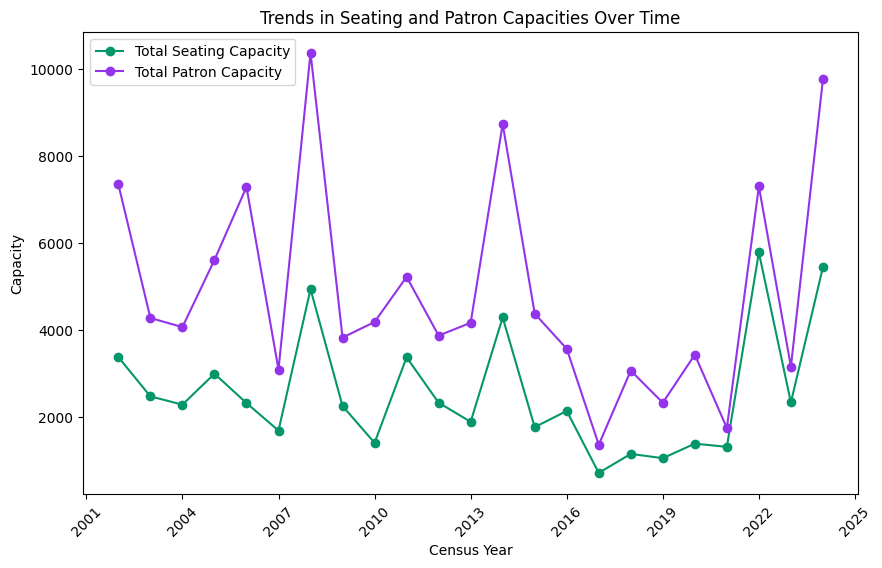

In [29]:
# Group data by census year and sum capacities
time_series = merged_df.groupby('census_year_bars').agg({'number_of_seats': 'sum', 'number_of_patrons': 'sum'}).reset_index()

# Plot the trends over time with whole number years on the x-axis
plt.figure(figsize=(10, 6))
plt.plot(time_series['census_year_bars'], time_series['number_of_seats'], label='Total Seating Capacity', marker='o', color=MOP_PALETTE[0])
plt.plot(time_series['census_year_bars'], time_series['number_of_patrons'], label='Total Patron Capacity', marker='o', color=MOP_PALETTE[1])
plt.title('Trends in Seating and Patron Capacities Over Time')
plt.xlabel('Census Year')
plt.ylabel('Capacity')
plt.xticks(time_series['census_year_bars'], rotation=45)
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.legend()
plt.show()


<div class="usecase-body">Interpret this chart with care. After de-duplication each property appears only once, filed under the census year in which its patron capacity was highest, and its seating figure is its highest cafe or restaurant record, which may come from a different year. Each total therefore reflects the properties whose peak fell in that year. It is not a complete count of capacity across the city in each year.</div>

<div id="subsection-3-14" class="usecase-sub-section-heading"><b>3.14 Boxplot for Seating Capacity Among Different Industries</b></div>

<div class="usecase-body">Compare seating capacity across industry classifications with a box plot per classification. Records with more than 1000 seats are excluded so the extreme values do not compress the rest of the chart.</div>

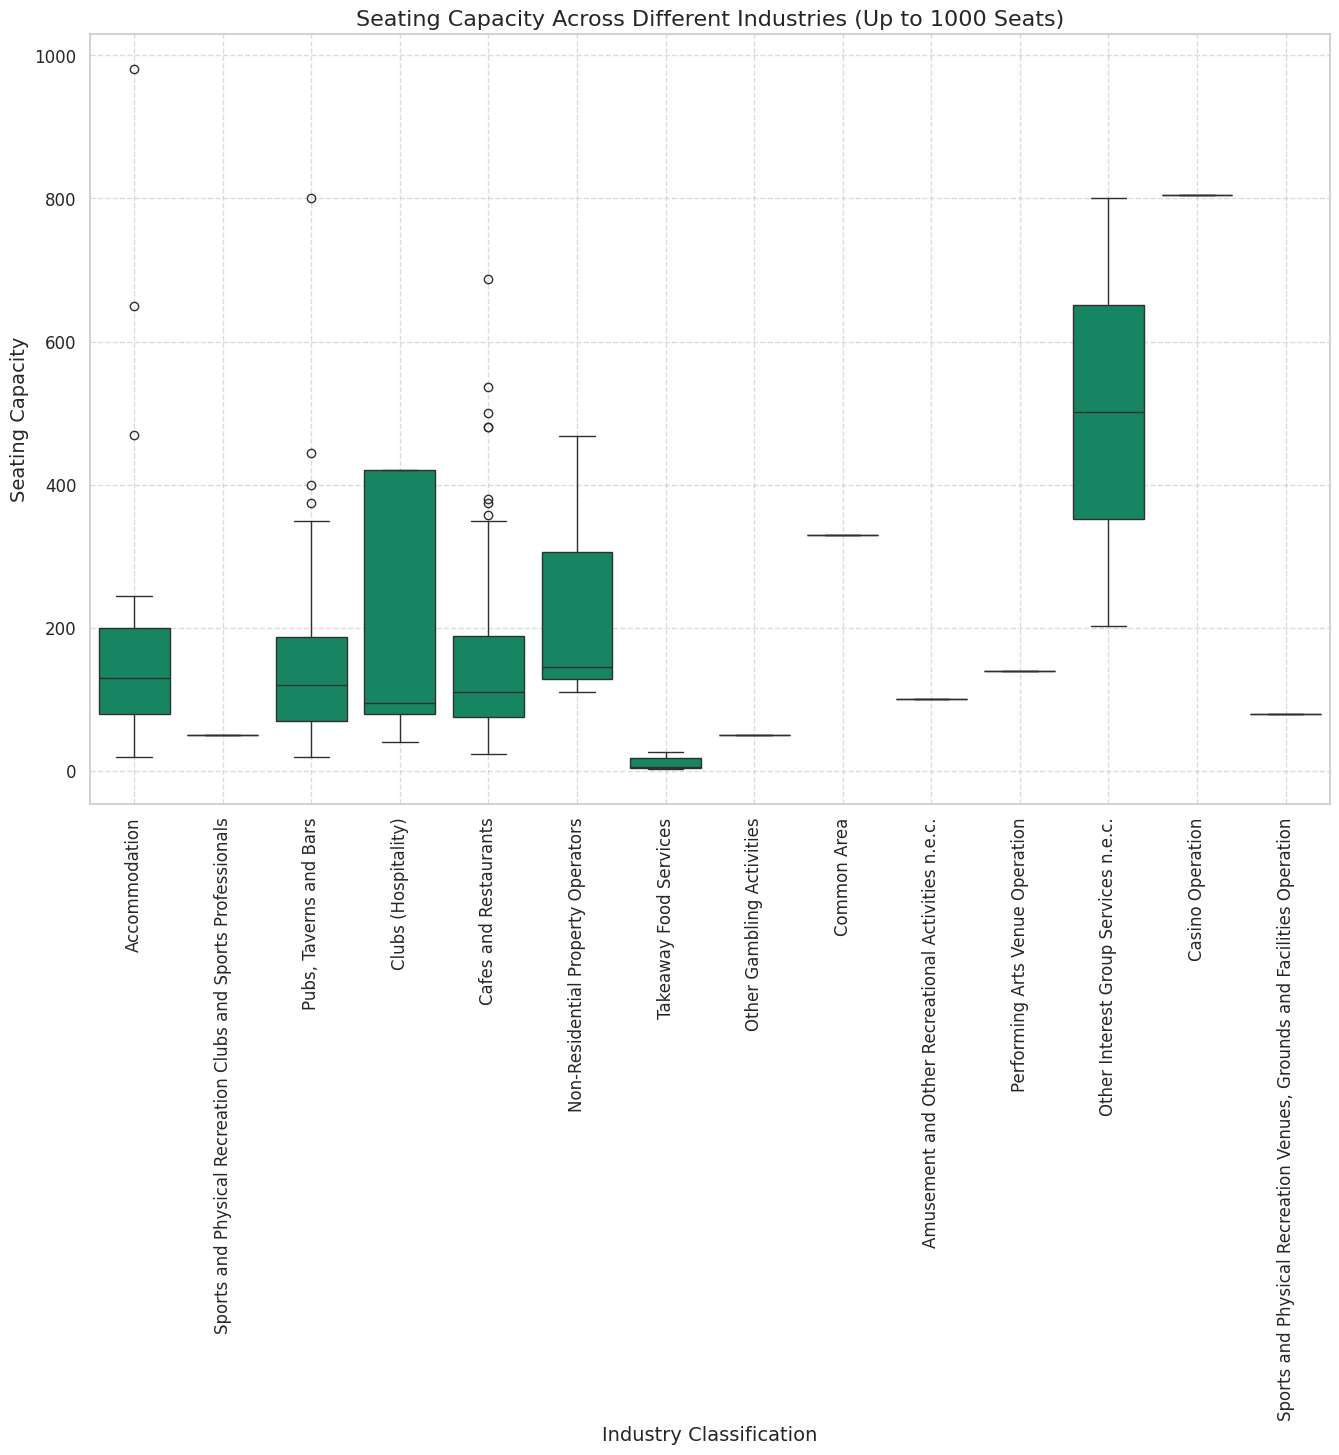

In [30]:
# Filter the dataframe to include only entries with seating capacities up to 1000
filtered_df = merged_df[merged_df['number_of_seats'] <= 1000]

# Set the style and context for the plot
sns.set(style="whitegrid")
plt.figure(figsize=(16, 10))

# One MOP colour for every box - industries are already labelled on the x-axis,
# and there are far more industries than colours in the template palette
sns.boxplot(
    x='industry_anzsic4_description',
    y='number_of_seats',
    data=filtered_df,
    color=MOP_GREEN
)

# Title and labels
plt.title('Seating Capacity Across Different Industries (Up to 1000 Seats)', fontsize=16)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Industry Classification', fontsize=14)
plt.ylabel('Seating Capacity', fontsize=14)

# Add gridlines for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.show()

<div class="usecase-body">The median and spread of seating capacity differ between industries. Classifications with only one or a few records appear as a flat line or a narrow box, so they are not directly comparable with the larger groups.</div>

<div id="subsection-3-15" class="usecase-sub-section-heading"><b>3.15 Seating Capacity by Industry and Seating Type</b></div>

<div class="usecase-body">Add up the seating capacity for each combination of industry classification and seating type (indoor or outdoor), and show the totals as grouped bars.</div>

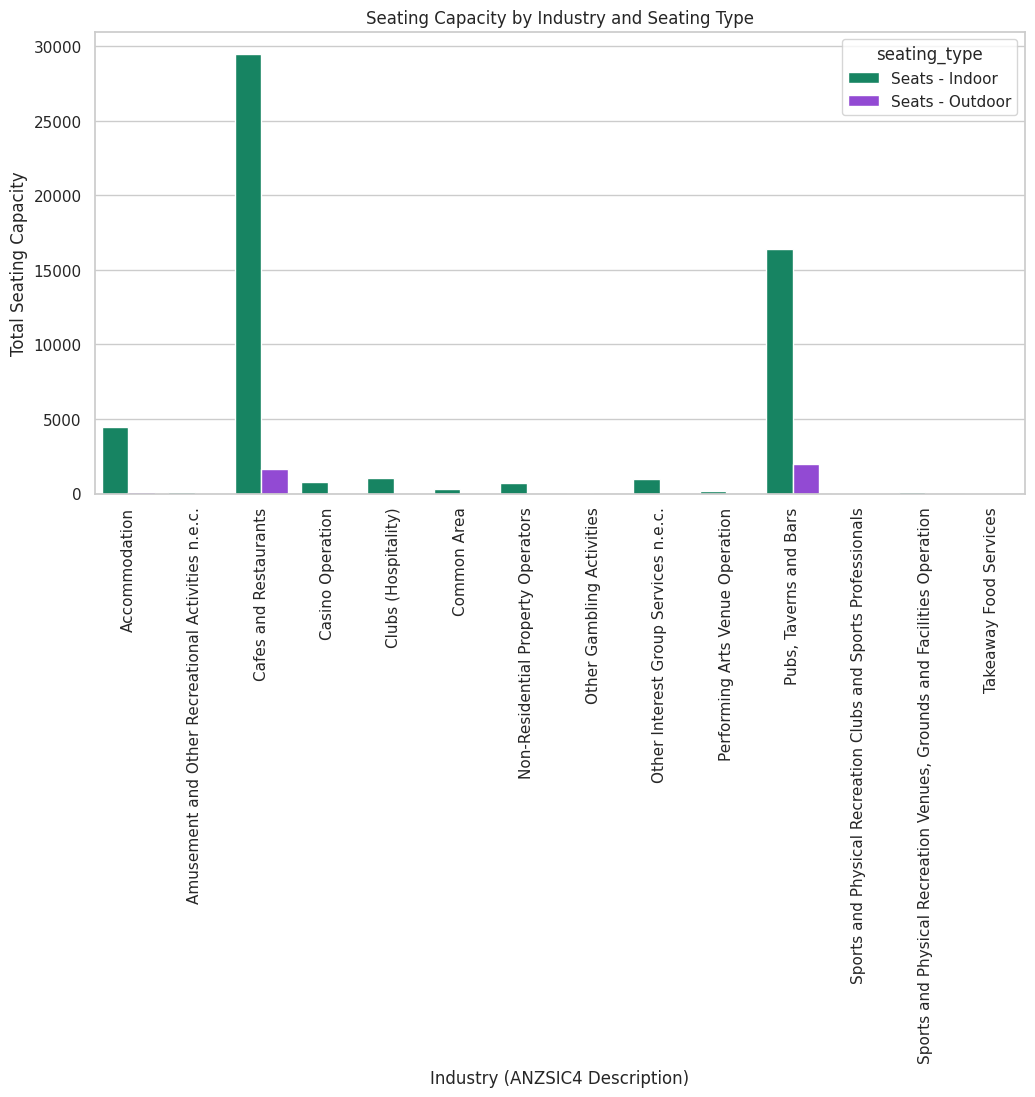

In [31]:
# Group by industry classification and seating type, then sum capacities
industry_seating = merged_df.groupby(['industry_anzsic4_description', 'seating_type']).agg({'number_of_seats': 'sum'}).reset_index()

# Plot the industry vs. seating type
plt.figure(figsize=(12, 6))
n_seating_types = industry_seating['seating_type'].nunique()
seating_type_palette = (MOP_PALETTE * ((n_seating_types // len(MOP_PALETTE)) + 1))[:n_seating_types]
sns.barplot(x='industry_anzsic4_description', y='number_of_seats', hue='seating_type', data=industry_seating, palette=seating_type_palette)
plt.title('Seating Capacity by Industry and Seating Type')
plt.xlabel('Industry (ANZSIC4 Description)')
plt.ylabel('Total Seating Capacity')
plt.xticks(rotation=90)
plt.show()


<div class="usecase-body">Indoor seating exceeds outdoor seating in every classification that has both. Cafes and Restaurants and Pubs, Taverns and Bars account for the largest totals.</div>

<div id="section-4" class="usecase-section-heading"><b>4. Analysing Seating Capacity by Location</b></div>

<div class="usecase-body">This section uses the merged dataset to summarise seating capacity by address, including where capacity is concentrated and how it relates to the number of venue records at each address.</div>

<div id="subsection-4-1" class="usecase-sub-section-heading"><b>4.1 Filter Data Based on Business Type</b></div>

<div class="usecase-body">Keep only the properties classified as <b>Cafes and Restaurants</b> or <b>Pubs, Taverns and Bars</b>, so the location analysis focuses on the two main venue types.</div>

In [32]:
# Filter the data for specific industries
restaurants_cafes_df = merged_df[merged_df['industry_anzsic4_description'].isin(['Cafes and Restaurants', 'Pubs, Taverns and Bars'])]

# Show the filtered data
print(restaurants_cafes_df.head())

   census_year_bars  property_id                   building_address_bars  \
2              2005       100727           5-9 Bank Place MELBOURNE 3000   
4              2003       101023         25 Bennetts Lane MELBOURNE 3000   
5              2002       101109      39-43 Bourke Street MELBOURNE 3000   
6              2008       101113      59-63 Bourke Street MELBOURNE 3000   
7              2023       101116  79-85 Bourke Street MELBOURNE VIC 3000   

  clue_small_area_bars        trading_name_bars  number_of_patrons  \
2      Melbourne (CBD)             Mitre Tavern                300   
4      Melbourne (CBD)  Bennetts Lane Jazz Club                360   
5      Melbourne (CBD)           Spleen Central                100   
6      Melbourne (CBD)           Madam Brussels                256   
7      Melbourne (CBD)             Good Heavens                400   

                 location_bars  latitude_bars  longitude_bars  \
2  -37.81680593, 144.960320678     -37.816806      144.96

<div class="usecase-body">The filtered data keeps the columns from both datasets, including the number of patrons, seating type and seating capacity.</div>

<div id="subsection-4-2" class="usecase-sub-section-heading"><b>4.2 Analyse the Distribution of Seating Capacities</b></div>

<div class="usecase-body">A histogram shows how seating capacity is distributed across the filtered venues.</div>

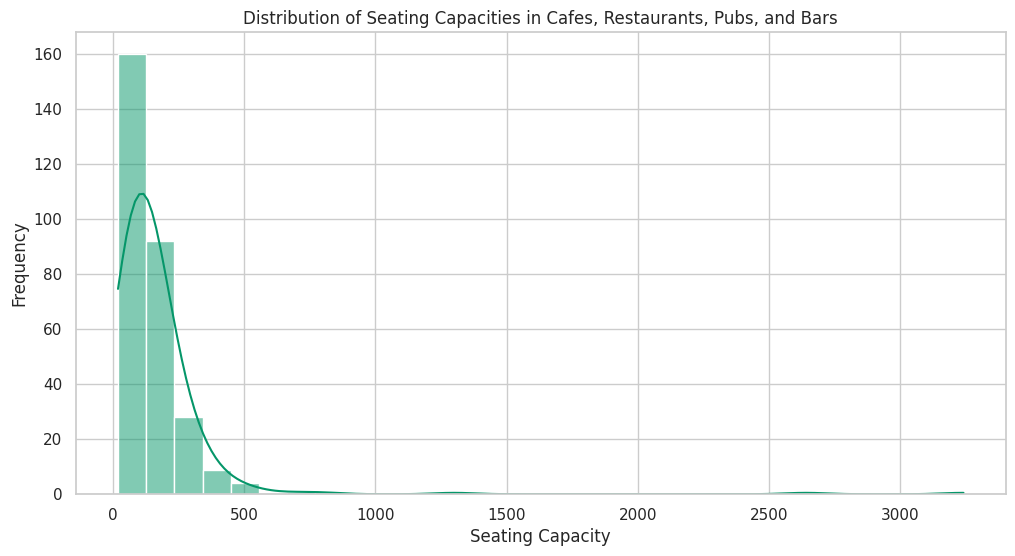

In [33]:
# Plot distribution of seating capacities
plt.figure(figsize=(12, 6))
sns.histplot(restaurants_cafes_df['number_of_seats'], bins=30, kde=True, color=MOP_GREEN)
plt.title('Distribution of Seating Capacities in Cafes, Restaurants, Pubs, and Bars')
plt.xlabel('Seating Capacity')
plt.ylabel('Frequency')
plt.show()

<div class="usecase-body">The distribution is right-skewed. Most venues have a seating capacity below 500, and a small number of much larger venues extend the right-hand tail.</div>

<div id="subsection-4-3" class="usecase-sub-section-heading"><b>4.3 Identify High-Capacity Locations</b></div>

<div class="usecase-body">Add up the seating capacity at each building address and sort from largest to smallest, so the addresses with the greatest total seating appear first.</div>

In [34]:
# Group by location and calculate total seating capacity for each
location_seating_capacity = restaurants_cafes_df.groupby('building_address_cafes')['number_of_seats'].sum().reset_index()

# Sort by seating capacity to identify high-capacity locations
high_capacity_locations = location_seating_capacity.sort_values(by='number_of_seats', ascending=False)

# Display top locations
print(high_capacity_locations.head(10))

                                building_address_cafes  number_of_seats
32                    120 Brunton Avenue JOLIMONT 3002             3240
36            122-148 Harbour Esplanade DOCKLANDS 3008             2640
282  McPherson's Building 546-566 Collins Street ME...             1300
91                    2 Swanston Street MELBOURNE 3000              880
75              183-265 La Trobe Street MELBOURNE 3000              867
237                   557 St Kilda Road MELBOURNE 3004              800
101             21-31 Market Street MELBOURNE VIC 3000              537
90          2 Convention Centre Place SOUTH WHARF 3006              500
107          221 Little Lonsdale Street MELBOURNE 3000              481
207             425-427 Docklands Drive DOCKLANDS 3008              480


<div class="usecase-body">The table lists the ten addresses with the highest total seating capacity. An address can hold several venues, so its total is the sum across them.</div>

<div id="subsection-4-4" class="usecase-sub-section-heading"><b>4.4 Visualise High-Capacity Locations</b></div>

<div class="usecase-body">Plot the ten addresses from the previous step as a horizontal bar chart to compare their totals.</div>

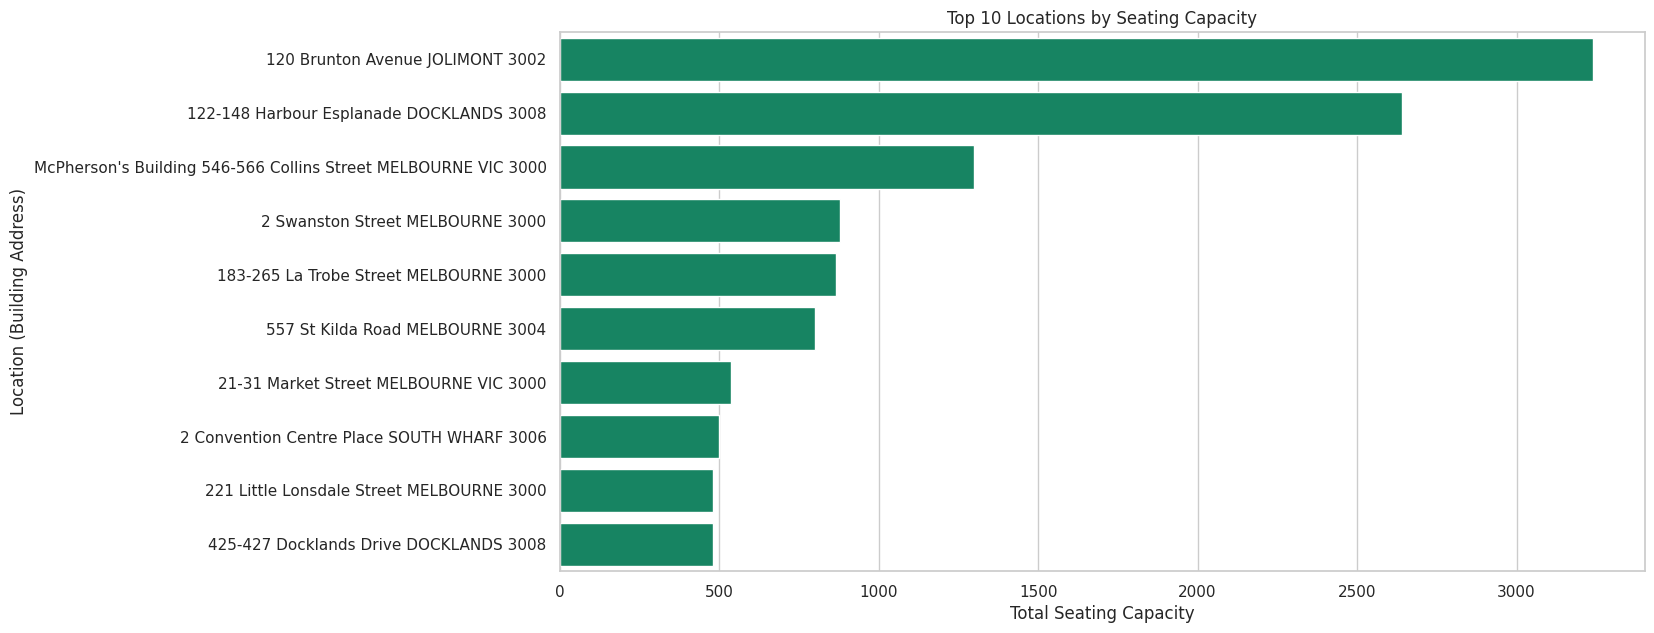

In [35]:
# Plot top 10 locations with highest seating capacities
plt.figure(figsize=(14, 7))
sns.barplot(x='number_of_seats', y='building_address_cafes', data=high_capacity_locations.head(10), color=MOP_GREEN)
plt.title('Top 10 Locations by Seating Capacity')
plt.xlabel('Total Seating Capacity')
plt.ylabel('Location (Building Address)')
plt.show()

<div class="usecase-body">The chart shows how the highest-capacity addresses compare with one another. The largest address stands well above the others.</div>

<div id="subsection-4-5" class="usecase-sub-section-heading"><b>4.5 Locations with High Capacity and Many Venue Records</b></div>

<div class="usecase-body">This step combines two measures for each address: total seating capacity and the number of venue records. The code finds the ten addresses with the most venue records, then keeps those with more than 500 seats in total.</div>

In [36]:
# Find the ten addresses with the most venue records
frequent_addresses = restaurants_cafes_df['building_address_cafes'].value_counts().index[:10]

# Keep those with more than 500 seats in total
high_capacity_frequent_addresses = location_seating_capacity[
    (location_seating_capacity['number_of_seats'] > 500) &
    (location_seating_capacity['building_address_cafes'].isin(frequent_addresses))
]

# Display these locations
print(high_capacity_frequent_addresses)


                    building_address_cafes  number_of_seats
75  183-265 La Trobe Street MELBOURNE 3000              867
91        2 Swanston Street MELBOURNE 3000              880


<div class="usecase-body">The printed rows are addresses that have both a high total seating capacity and a large number of venue records.</div>

<div id="subsection-4-6" class="usecase-sub-section-heading"><b>4.6 Mapping Locations with High Capacity and Fewer Venues</b></div>

<div class="usecase-body">This step looks at the opposite end of the venue count. For each address the code adds up the seating capacity and counts the venue records, keeps addresses with more than 1000 seats in total but fewer than 5 venue records, and draws a green circle at each one on a Folium map. Clicking a circle shows its trading name and the total seats at that address.</div>

In [37]:
# Group by location and calculate total seating capacity and the number of businesses
location_analysis = restaurants_cafes_df.groupby('building_address_cafes').agg({
    'number_of_seats': 'sum',
    'trading_name_bars': 'count'
}).reset_index()

# Rename columns for clarity
location_analysis.columns = ['Location', 'Total_Seating_Capacity', 'Number_of_Businesses']

# Filter for high-capacity locations
high_capacity_locations = location_analysis[location_analysis['Total_Seating_Capacity'] > 1000]

# Identify locations with fewer venues
high_capacity_fewer_venues = high_capacity_locations[high_capacity_locations['Number_of_Businesses'] < 5]

# Merge with the original dataframe to get latitude and longitude
merged_map_data = pd.merge(high_capacity_fewer_venues, restaurants_cafes_df, left_on='Location', right_on='building_address_cafes')

# Drop duplicates to avoid multiple entries for the same location
merged_map_data = merged_map_data.drop_duplicates(subset=['Location'])

# Initialise a folium map centred around Melbourne
m = folium.Map(location=[-37.8136, 144.9631], zoom_start=12, tiles=MAP_TILES, attr=MAP_ATTR)

# Add circles for high-capacity locations with fewer venues
for _, row in merged_map_data.iterrows():
    location = [float(coord) for coord in row['location_cafes'].split(', ')]
    popup_text = f"{row['trading_name_bars']}: Seats {row['number_of_seats']}, Total Seats in Area: {row['Total_Seating_Capacity']}"
    folium.Circle(
        location=location,
        radius=200,  # Adjust the radius as needed
        color=MOP_GREEN,
        fill=True,
        fill_opacity=0.4,
        popup=popup_text
    ).add_to(m)

# Add a legend
legend_html = f"""
<div style="position: fixed;
            bottom: 50px; left: 50px; width: 200px; height: 90px;
            background-color: white; z-index:9999; font-size:14px;">
    <b>&nbsp; Legend </b><br>
    &nbsp; <i class="fa fa-circle" style="color:{MOP_GREEN}"></i> High Capacity, Fewer Venues
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Display the map
m

<div class="usecase-body">Each circle marks an address with a high seating total spread across relatively few venue records. The legend in the corner explains the circle colour.</div>

<div id="section-5" class="usecase-section-heading"><b>5. Predicting Future Seating and Patron Capacities</b></div>

<div class="usecase-body">This section forecasts capacity in two ways. An ARIMA time series model forecasts one property from its own history. A Random Forest model is trained across all properties and uses features such as location, year and previous capacity. Together they show how each approach is built and evaluated.</div>

<div id="subsection-5-1" class="usecase-sub-section-heading"><b>5.1 Time Series (ARIMA) Model to Predict Patron and Seating Capacities</b></div>

<div class="usecase-body">ARIMA (AutoRegressive Integrated Moving Average) forecasts a single series from its own past values. Here the series is one property's capacity across census years. The order <code>(1, 1, 1)</code> sets one autoregressive term, one round of differencing to remove a trend, and one moving-average term. Because each property has only a few census years, ARIMA needs enough history to detect a trend, and the code falls back to a simple baseline when there is too little.</div>

<div id="subsubsection-5-1-1" class="usecase-sub-sub-section-heading"><b>5.1.1 Data Preparation</b></div>

<div class="usecase-body">Add up capacity for each property, census year and trading name, so the data is one value per property per year. This uses the cleaned datasets from before de-duplication, because forecasting needs every census year for a property rather than only its highest year.</div>

In [38]:
# Aggregating data for cafes/restaurants by property_id and census_year
cafes_restaurants_agg = cafes_restaurants_updated.groupby(['property_id', 'census_year', 'trading_name']).agg({
    'number_of_seats': 'sum'
}).reset_index()

# Aggregating data for bars/pubs by property_id and census_year
bars_pubs_agg = bars_pubs_updated.groupby(['property_id', 'census_year', 'trading_name']).agg({
    'number_of_patrons': 'sum'
}).reset_index()

# Display the aggregated data
print("Aggregated Cafes and Restaurants Data:")
print(cafes_restaurants_agg.head())

print("\nAggregated Bars and Pubs Data:")
print(bars_pubs_agg.head())

Aggregated Cafes and Restaurants Data:
   property_id  census_year                 trading_name  number_of_seats
0       100041         2002              Abbot's Seafood               10
1       100084         2002           La Dish Fine Foods               28
2       100112         2002  Papa Guiseppe Pizza & Pasta               12
3       100112         2003  Papa Guiseppe Pizza & Pasta               12
4       100112         2004  Papa Guiseppe Pizza & Pasta               12

Aggregated Bars and Pubs Data:
   property_id  census_year                 trading_name  number_of_patrons
0       100160         2008  Nomads Industry Backpackers                200
1       100160         2009  Nomads Industry Backpackers                200
2       100160         2010  Nomads Industry Backpackers                200
3       100160         2011  Nomads Industry Backpackers                200
4       100160         2012  Nomads Industry Backpackers                200


<div class="usecase-body">Each row is now one property in one census year with its total capacity, which is the shape ARIMA needs.</div>

<div id="subsubsection-5-1-2" class="usecase-sub-sub-section-heading"><b>5.1.2 Time Series Forecasting for Cafes and Restaurants</b></div>

<div class="usecase-body">Set <code>property_id</code> to the property you want to forecast. By default the code picks the property with the longest census history whose capacity has changed over time, so the model has a trend to learn. It first combines records so there is one value per census year, then counts the years. If fewer than four are available, ARIMA is not fitted and the last recorded value is carried forward as a simple baseline. When at least five years are available it also runs a one-step holdout check, which trains the model on all but the last year, predicts that last year and compares the prediction with the actual value. The model is then fitted on the full history and forecasts the next five years.</div>

In [39]:
# Property to forecast. By default this is the property with the longest census history whose capacity
# has changed over time, so the model has a trend to learn. Replace it with any property_id from cafes_restaurants_agg.
history = cafes_restaurants_agg.groupby(['property_id', 'census_year'])['number_of_seats'].sum().groupby('property_id').agg(['count', 'nunique'])
property_id = history[history['nunique'] > 1].sort_values(['count', 'nunique'], ascending=False).index[0]

if property_id not in cafes_restaurants_agg['property_id'].values:
    print(f"Property ID {property_id} is invalid. Please enter a valid property ID.")
else:
    # One value per census year (a property can list several trading names in the same year)
    seats_by_year = (
        cafes_restaurants_agg[cafes_restaurants_agg['property_id'] == property_id]
        .groupby('census_year')['number_of_seats'].sum()
        .sort_index()
    )
    years = seats_by_year.index.astype(int).tolist()
    seats_values = seats_by_year.to_numpy(dtype=float)
    n_obs = len(seats_values)
    future_years = list(range(years[-1] + 1, years[-1] + 6))
    print(f"Property {property_id} has {n_obs} census year(s) of history ({years[0]} to {years[-1]}).")

    if n_obs < 4:
        print("This is not enough history to fit an ARIMA model, so the last recorded value is carried forward as a simple baseline.")
        forecast_seats = np.repeat(seats_values[-1], 5)
    else:
        if n_obs >= 5:
            try:
                holdout_fit = ARIMA(seats_values[:-1], order=(1, 1, 1)).fit()
                holdout_forecast = holdout_fit.forecast(steps=1)[0]
                actual_last = seats_values[-1]
                print(f"One step holdout check: predicted {holdout_forecast:.1f} versus actual {actual_last:.0f}, absolute error {abs(holdout_forecast - actual_last):.1f}")
            except Exception as e:
                print(f"Holdout check could not be computed for property {property_id}: {e}")
        else:
            print(f"Not enough history ({n_obs} years) to run a holdout accuracy check for property {property_id}.")

        # The model is fitted on the values only, because a property's census years are not always evenly spaced
        model_seats_fit = ARIMA(seats_values, order=(1, 1, 1)).fit()
        forecast_seats = model_seats_fit.forecast(steps=5)

    forecast_seats_df = pd.DataFrame({'census_year': future_years, 'forecast_number_of_seats': np.round(forecast_seats, 1)})
    print(f"\nFuture seating capacity forecast for property {property_id} ({future_years[0]} to {future_years[-1]}):")
    print(forecast_seats_df.to_string(index=False))

Property 102063 has 23 census year(s) of history (2002 to 2024).
One step holdout check: predicted 391.6 versus actual 127, absolute error 264.6

Future seating capacity forecast for property 102063 (2025 to 2029):
 census_year  forecast_number_of_seats
        2025                      66.4
        2026                      87.8
        2027                      80.2
        2028                      82.9
        2029                      82.0


<div class="usecase-body">The output lists a forecast for each of the five years after the property's last census year. The model is fitted on the sequence of values rather than on the year labels, because a property's census years are not always evenly spaced. When a property has only a few years of history the forecast is often flat, so treat it as low confidence. Change <code>property_id</code> to compare properties with different histories.</div>

<div id="subsubsection-5-1-3" class="usecase-sub-sub-section-heading"><b>5.1.3 Time Series Forecasting for Bars and Pubs</b></div>

<div class="usecase-body">The same steps are applied to a bars and pubs property, forecasting <code>number_of_patrons</code>.</div>

In [40]:
# Property to forecast. By default this is the property with the longest census history whose capacity
# has changed over time, so the model has a trend to learn. Replace it with any property_id from bars_pubs_agg.
history = bars_pubs_agg.groupby(['property_id', 'census_year'])['number_of_patrons'].sum().groupby('property_id').agg(['count', 'nunique'])
property_id = history[history['nunique'] > 1].sort_values(['count', 'nunique'], ascending=False).index[0]

if property_id not in bars_pubs_agg['property_id'].values:
    print(f"Property ID {property_id} is invalid. Please enter a valid property ID.")
else:
    # One value per census year (a property can list several trading names in the same year)
    patrons_by_year = (
        bars_pubs_agg[bars_pubs_agg['property_id'] == property_id]
        .groupby('census_year')['number_of_patrons'].sum()
        .sort_index()
    )
    years = patrons_by_year.index.astype(int).tolist()
    patrons_values = patrons_by_year.to_numpy(dtype=float)
    n_obs = len(patrons_values)
    future_years = list(range(years[-1] + 1, years[-1] + 6))
    print(f"Property {property_id} has {n_obs} census year(s) of history ({years[0]} to {years[-1]}).")

    if n_obs < 4:
        print("This is not enough history to fit an ARIMA model, so the last recorded value is carried forward as a simple baseline.")
        forecast_patrons = np.repeat(patrons_values[-1], 5)
    else:
        if n_obs >= 5:
            try:
                holdout_fit = ARIMA(patrons_values[:-1], order=(1, 1, 1)).fit()
                holdout_forecast = holdout_fit.forecast(steps=1)[0]
                actual_last = patrons_values[-1]
                print(f"One step holdout check: predicted {holdout_forecast:.1f} versus actual {actual_last:.0f}, absolute error {abs(holdout_forecast - actual_last):.1f}")
            except Exception as e:
                print(f"Holdout check could not be computed for property {property_id}: {e}")
        else:
            print(f"Not enough history ({n_obs} years) to run a holdout accuracy check for property {property_id}.")

        # The model is fitted on the values only, because a property's census years are not always evenly spaced
        model_patrons_fit = ARIMA(patrons_values, order=(1, 1, 1)).fit()
        forecast_patrons = model_patrons_fit.forecast(steps=5)

    forecast_patrons_df = pd.DataFrame({'census_year': future_years, 'forecast_number_of_patrons': np.round(forecast_patrons, 1)})
    print(f"\nFuture patron capacity forecast for property {property_id} ({future_years[0]} to {future_years[-1]}):")
    print(forecast_patrons_df.to_string(index=False))

Property 558180 has 23 census year(s) of history (2002 to 2024).
One step holdout check: predicted 4999.9 versus actual 5000, absolute error 0.1

Future patron capacity forecast for property 558180 (2025 to 2029):
 census_year  forecast_number_of_patrons
        2025                      4999.9
        2026                      4999.8
        2027                      4999.7
        2028                      4999.7
        2029                      4999.6


<div class="usecase-body">The output has the same layout as the previous step: the length of the history, a holdout check when enough history is available, and the forecast for the next five years. Try other property IDs from <code>bars_pubs_agg</code>.</div>

<div id="subsection-5-2" class="usecase-sub-section-heading"><b>5.2 Random Forest Model to Predict Patron and Seating Capacities</b></div>

<div class="usecase-body">A Random Forest is an ensemble of decision trees whose predictions are averaged. Unlike ARIMA, a single model is trained on all properties at once and learns from features such as census year, location, industry and the property's previous capacity.</div>

<div id="subsubsection-5-2-1" class="usecase-sub-sub-section-heading"><b>5.2.1 Data Preprocessing and Feature Engineering</b></div>

<div class="usecase-body">Prepare the features. The code sorts each dataset by property and census year, forward fills any gaps, and creates two new columns: <code>capacity_change</code>, the difference from the previous census year, and <code>prev_number_of_patrons</code> or <code>prev_number_of_seats</code>, the property's capacity in the previous census year. The previous capacity gives the model real information about each property. For a property's first recorded year, where no earlier value exists, its own current value is used as the starting point.</div>

In [41]:
# Grouping by property_id and sorting by census_year
bars_pubs_sorted = bars_pubs_updated.sort_values(by=['property_id', 'census_year'])
cafes_restaurants_sorted = cafes_restaurants_updated.sort_values(by=['property_id', 'census_year'])

# Handling missing values (forward fill)
bars_pubs_sorted = bars_pubs_sorted.ffill()
cafes_restaurants_sorted = cafes_restaurants_sorted.ffill()

# Adding time-based features (difference in capacity from the previous year)
bars_pubs_sorted['capacity_change'] = bars_pubs_sorted.groupby('property_id')['number_of_patrons'].diff()
cafes_restaurants_sorted['capacity_change'] = cafes_restaurants_sorted.groupby('property_id')['number_of_seats'].diff()

# Historical capacity feature: the property's own capacity in the previous census year
# This is what actually lets the model generalise, since it gives real signal about a property instead of memorising an ID
bars_pubs_sorted['prev_number_of_patrons'] = bars_pubs_sorted.groupby('property_id')['number_of_patrons'].shift(1)
cafes_restaurants_sorted['prev_number_of_seats'] = cafes_restaurants_sorted.groupby('property_id')['number_of_seats'].shift(1)

# For a property's first recorded year there is no earlier value, so use its own current value as the starting point
bars_pubs_sorted['prev_number_of_patrons'] = bars_pubs_sorted['prev_number_of_patrons'].fillna(bars_pubs_sorted['number_of_patrons'])
cafes_restaurants_sorted['prev_number_of_seats'] = cafes_restaurants_sorted['prev_number_of_seats'].fillna(cafes_restaurants_sorted['number_of_seats'])

<div class="usecase-body">This cell prepares the data and prints nothing. The new columns are used in the next step.</div>

<div id="subsubsection-5-2-2" class="usecase-sub-sub-section-heading"><b>5.2.2 Model Training</b></div>

<div class="usecase-body">Convert the categorical columns (such as location and seating type) into numeric indicator columns with <code>get_dummies</code>, split each dataset into 80 per cent training and 20 per cent testing data, and train a Random Forest of 100 trees for each dataset. The models are evaluated on the test data with two measures. <b>Mean squared error (MSE)</b> is the average of the squared prediction errors, so lower is better and it is in squared units of the target. <b>R²</b> is the share of the variation in capacity that the model explains, where 1 is a perfect fit.</div>

In [ ]:
from sklearn.metrics import r2_score

# Bars and Pubs features: census year, location (CLUE area), and the property's own recent history
bars_pubs_features = pd.get_dummies(
    bars_pubs_sorted[['census_year', 'clue_small_area', 'prev_number_of_patrons']],
    columns=['clue_small_area']
)
y_bars_pubs = bars_pubs_sorted['number_of_patrons']

# Cafes and Restaurants features: census year, location, industry type, seating type, and recent history
cafes_restaurants_features = pd.get_dummies(
    cafes_restaurants_sorted[['census_year', 'clue_small_area', 'industry_anzsic4_description', 'seating_type', 'prev_number_of_seats']],
    columns=['clue_small_area', 'industry_anzsic4_description', 'seating_type']
)
y_cafes_restaurants = cafes_restaurants_sorted['number_of_seats']

# Train/test split
X_train_bars, X_test_bars, y_train_bars, y_test_bars = train_test_split(bars_pubs_features, y_bars_pubs, test_size=0.2, random_state=42)
X_train_cafes, X_test_cafes, y_train_cafes, y_test_cafes = train_test_split(cafes_restaurants_features, y_cafes_restaurants, test_size=0.2, random_state=42)

# Random Forest Model
rf_bars = RandomForestRegressor(n_estimators=100, random_state=42)
rf_bars.fit(X_train_bars, y_train_bars)

rf_cafes = RandomForestRegressor(n_estimators=100, random_state=42)
rf_cafes.fit(X_train_cafes, y_train_cafes)

# Predictions and evaluation
y_pred_bars = rf_bars.predict(X_test_bars)
y_pred_cafes = rf_cafes.predict(X_test_cafes)

mse_bars = mean_squared_error(y_test_bars, y_pred_bars)
mse_cafes = mean_squared_error(y_test_cafes, y_pred_cafes)

r2_bars = r2_score(y_test_bars, y_pred_bars)
r2_cafes = r2_score(y_test_cafes, y_pred_cafes)

print(f'Bars and Pubs: MSE {mse_bars:.2f}, R2 {r2_bars:.3f}')
print(f'Cafes and Restaurants: MSE {mse_cafes:.2f}, R2 {r2_cafes:.3f}')

<div class="usecase-body">The cell prints the MSE and R² for each model. The exact values can change when the datasets are refreshed or library versions differ, so use them to compare the two models rather than as fixed benchmarks. The split is random, so a property can appear in both the training and test data, which means the scores are likely to look better than for properties the model has never seen.</div>

<div id="subsubsection-5-2-3" class="usecase-sub-sub-section-heading"><b>5.2.3 Prediction for Future Years (2024 to 2028)</b></div>

<div class="usecase-body">The <code>predict_future_capacity</code> function predicts one year at a time. For each future year it builds a row using the year, the property's latest known capacity and its categorical values, matches the columns to those used in training, and predicts. Each prediction then becomes the previous capacity for the following year. The dropdown selects a property, and if the property appears in both datasets, predictions are shown for both.</div>

In [ ]:
def predict_future_capacity(model, train_columns, dataset, property_id, capacity_column, categorical_columns, prev_column, years_to_predict=5, start_year=2024):
    property_rows = dataset[dataset['property_id'] == property_id].copy()

    if property_rows.empty:
        print(f"No data found for property_id: {property_id}")
        return None

    latest = property_rows.sort_values('census_year').iloc[-1]
    current_capacity = latest[capacity_column]

    predictions = []
    for i in range(years_to_predict):
        year = start_year + i
        row = {'census_year': year, prev_column: current_capacity}
        for col in categorical_columns:
            row[col] = latest[col]

        row_df = pd.DataFrame([row])
        row_encoded = pd.get_dummies(row_df, columns=categorical_columns)
        row_encoded = row_encoded.reindex(columns=train_columns, fill_value=0)

        pred = int(round(model.predict(row_encoded)[0]))
        predictions.append({'census_year': year, capacity_column: pred})
        current_capacity = pred

    result = pd.DataFrame(predictions)
    print(f"Predicted {capacity_column} for property_id {property_id} for the years {start_year} to {start_year + years_to_predict - 1}:")
    print(result.to_string(index=False))
    return result


def predict_future_capacity_combined(bars_model, cafes_model, bars_dataset, cafes_dataset, bars_train_columns, cafes_train_columns, property_id, years_to_predict=5, start_year=2024):
    in_bars = not bars_dataset[bars_dataset['property_id'] == property_id].empty
    in_cafes = not cafes_dataset[cafes_dataset['property_id'] == property_id].empty

    if not in_bars and not in_cafes:
        print(f"No data found for property_id: {property_id} in either dataset.")
        return

    if in_bars:
        trading_name_bars = bars_dataset[bars_dataset['property_id'] == property_id]['trading_name'].values[0]
        print(f"\nProperty ID {property_id} ({trading_name_bars}) found in Bars and Pubs dataset:")
        predict_future_capacity(bars_model, bars_train_columns, bars_dataset, property_id, 'number_of_patrons', ['clue_small_area'], 'prev_number_of_patrons', years_to_predict, start_year)

    if in_cafes:
        trading_name_cafes = cafes_dataset[cafes_dataset['property_id'] == property_id]['trading_name'].values[0]
        print(f"\nProperty ID {property_id} ({trading_name_cafes}) found in Cafes and Restaurants dataset:")
        predict_future_capacity(cafes_model, cafes_train_columns, cafes_dataset, property_id, 'number_of_seats', ['clue_small_area', 'industry_anzsic4_description', 'seating_type'], 'prev_number_of_seats', years_to_predict, start_year)


# Dropdown widget replacing the input() call, matching the pattern already used for the maps earlier in the notebook
all_property_ids = sorted(set(bars_pubs_sorted['property_id'].unique()).union(set(cafes_restaurants_sorted['property_id'].unique())))

property_id_dropdown = widgets.Dropdown(
    options=all_property_ids,
    description='Property ID:'
)

def run_prediction(property_id):
    predict_future_capacity_combined(rf_bars, rf_cafes, bars_pubs_sorted, cafes_restaurants_sorted, X_train_bars.columns, X_train_cafes.columns, property_id)

widgets.interact(run_prediction, property_id=property_id_dropdown);

<div class="usecase-body">Choose a property ID in the dropdown to see its predicted capacity for 2024 to 2028. Because each year's prediction feeds the next, the predictions tend to stay close to the property's latest known capacity.</div>

<div id="conclusion" class="usecase-unnumbered-heading"><b>Conclusion</b></div>

<div class="usecase-body">This use case set out to analyse historical seating and patron capacity for Melbourne's bars, pubs, cafes and restaurants and forecast how capacity may change, as described in the Scenario. It worked from data retrieval through to two forecasting approaches.</div>

**What we achieved in this analysis**

<div class="usecase-list">

- Retrieved two City of Melbourne CLUE datasets through the Open Data API
- Cleaned the data by filling missing locations from other records at the same address, removing properties with no location, and de-duplicating to one record per property
- Explored capacity with distribution charts, industry comparisons and interactive maps
- Merged the datasets on property ID and measured the relationship between seating and patron capacity
- Summarised seating capacity by address and compared it with the number of venue records
- Forecast capacity for individual properties with ARIMA and trained Random Forest models evaluated with MSE and R²

</div>

**What we learned from this analysis**

<div class="usecase-list">

- Seating capacity and patron capacity are positively related, although a small number of very large venues sit well away from the trend
- Capacity is right-skewed: most venues are small to medium, and a few very large venues stretch the upper end of the distribution
- Many properties have only a short history in the census data, so ARIMA forecasts for a single property are often flat and need to be read with care
- MSE and R² depend on the data and on how it is split, so they are best used to compare models rather than as fixed benchmarks

</div>

**Observations for further opportunities**

<div class="usecase-list">

- The models use past capacity, location and industry only, because the datasets do not include measures of demand such as visitor numbers
- The City of Melbourne Open Data Platform also publishes datasets with a geographic dimension, such as pedestrian counts, that share location with these data
- The ARIMA approach forecasts one property at a time, while the Random Forest approach learns across all properties, so the two answer slightly different questions

</div>